In [2]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
from eigenshuffle import eigenshuffle_eig
import numpy as np
from scipy.optimize import linear_sum_assignment
import scienceplots

def track_eigenvalues(all_evals):
    T, N = all_evals.shape
    tracked_eigvals = np.zeros((T, N), dtype=np.complex128)
    
    # --- Paso t=0 ---
    idx_0 = np.argsort(all_evals[0].imag)
    tracked_eigvals[0] = all_evals[0][idx_0]
    
    # --- Paso t=1 ---
    prev_eigs = tracked_eigvals[0]
    curr_eigs = all_evals[1]

    cost_matrix = np.abs(prev_eigs[:, None] - curr_eigs[None, :])
    _, col_ind = linear_sum_assignment(cost_matrix)
    tracked_eigvals[1] = curr_eigs[col_ind]

    for t in range(2, T):

        velocidad = tracked_eigvals[t-1] - tracked_eigvals[t-2]
        prediccion = tracked_eigvals[t-1] + velocidad
        curr_eigs = all_evals[t]
        
        # 2. Matriz de Coste Mixta
        cost_matrix = np.abs(prediccion[:, None] - curr_eigs[None, :])
        
        # 3. Asignación (Algoritmo Húngaro)
        _, col_ind = linear_sum_assignment(cost_matrix)
        
        # 4. Guardar resultado (Ahora sí aplicará el orden correctamente)
        tracked_eigvals[t] = curr_eigs[col_ind]
        
    return tracked_eigvals

@njit(fastmath=True)
def hopfield(STEPS, W, X_0, DT):
    DIM = X_0.shape[0]
    X_time_series = np.zeros((STEPS, DIM))
    X_time_series[0] = X_0
    for t in range(1, STEPS):
        if t % 10 == 0:
            print(f"Paso {t}/{STEPS}")
        for i in range(DIM):
            sum = 0
            for j in range(DIM):
                sum += W[i, j] * X_time_series[t-1, j]

            X_time_series[t, i] = np.tanh(sum)
    
    return X_time_series

def ODE_system(t, y, dim, alpha):
    X = y[:dim]
    W = y[dim:].reshape((dim, dim))

    dim = np.shape(X)[0]
    dWdt = alpha * (np.eye(dim) - np.outer(X, X))
    dXdt = W @ X

    return np.concatenate([dXdt, dWdt.flatten()])

def track_eigen_complete_inertia(all_evals, all_evecs, alpha=0.1):
    """
    all_evals: array de dimensiones (T, N) con los autovalores precalculados.
    all_evecs: array de dimensiones (T, N, N) con los autovectores.
    """
    T, N = all_evals.shape
    tracked_evals = np.zeros((T, N), dtype=np.complex128)
    tracked_evecs = np.zeros((T, N, N), dtype=np.complex128)
    
    if T == 0:
        return tracked_evals, tracked_evecs
        
    idx_0 = np.argsort(all_evals[0].imag)
    tracked_evals[0] = all_evals[0][idx_0]
    tracked_evecs[0] = all_evecs[0][:, idx_0]
    
    if T == 1:
        return tracked_evals, tracked_evecs

    curr_evals = all_evals[1]
    prev_evals = tracked_evals[0]
    cost_matrix = np.abs(prev_evals[:, None] - curr_evals[None, :])
    _, col_ind = linear_sum_assignment(cost_matrix)
    tracked_evals[1] = curr_evals[col_ind]
    tracked_evecs[1] = all_evecs[1][:, col_ind]

    for t in range(2, T):
        curr_evals = all_evals[t]
        velocidad = tracked_evals[t-1] - tracked_evals[t-2]
        prediccion = tracked_evals[t-1] + velocidad
        
        curr_evecs = all_evecs[t]
        prev_evecs = tracked_evecs[t-1]

        # 1. Distancia pura de autovalores (sin normalización)
        cost_evals = np.abs(prediccion[:, None] - curr_evals[None, :])

        # 2. Proyección bi-ortogonal estricta (Autovectores Izquierdos x Derechos)
        L_prev = np.linalg.inv(prev_evecs)
        proyecciones = np.abs(L_prev @ curr_evecs)
        cost_evecs = 1.0 - proyecciones
        if t==50:
            print(cost_evecs)

        # 3. Matriz combinada
        cost_matrix = alpha * cost_evals + (1 - alpha) * cost_evecs

        _, col_ind = linear_sum_assignment(cost_matrix)        
        
        tracked_evals[t] = curr_evals[col_ind]
        tracked_evecs[t] = all_evecs[t, :, col_ind]
        
    return tracked_evals, tracked_evecs

def track_eigen_inertia(all_evals, all_evecs):
    """
    Ordena autovalores y autovectores a lo largo del tiempo basándose EXCLUSIVAMENTE
    en la inercia (predicción lineal) de la trayectoria de los autovalores.
    
    all_evals: array (T, N) de autovalores complejos.
    all_evecs: array (T, N, N) de autovectores complejos.
    """
    T, N = all_evals.shape
    tracked_evals = np.zeros((T, N), dtype=np.complex128)
    tracked_evecs = np.zeros((T, N, N), dtype=np.complex128)
    
    if T == 0:
        return tracked_evals, tracked_evecs
        
    # --- Paso t=0: Ordenar por parte imaginaria ---
    idx_0 = np.argsort(all_evals[0].imag)
    tracked_evals[0] = all_evals[0][idx_0]
    tracked_evecs[0] = all_evecs[0][:, idx_0]
    
    if T == 1:
        return tracked_evals, tracked_evecs

    # --- Paso t=1: Distancia pura (sin inercia aún) ---
    curr_evals = all_evals[1]
    prev_evals = tracked_evals[0]
    
    cost_matrix = np.abs(prev_evals[:, None] - curr_evals[None, :])
    _, col_ind = linear_sum_assignment(cost_matrix)
    
    tracked_evals[1] = curr_evals[col_ind]
    tracked_evecs[1] = all_evecs[1][:, col_ind]

    # --- Pasos t >= 2: Inercia / Predicción Lineal ---
    for t in range(2, T):
        curr_evals = all_evals[t]
        
        # 1. Calcular la velocidad (delta) del paso anterior
        velocidad = tracked_evals[t-1] - tracked_evals[t-2]
        
        # 2. Predecir la posición esperada en el paso actual
        prediccion = tracked_evals[t-1] + velocidad
        
        # 3. Matriz de costo: Distancia entre la PREDICCIÓN y los valores ACTUALES
        cost_matrix = np.abs(prediccion[:, None] - curr_evals[None, :])
        
        # 4. Asignación óptima con el algoritmo húngaro
        _, col_ind = linear_sum_assignment(cost_matrix)        
        
        # 5. Guardar los resultados ordenados
        tracked_evals[t] = curr_evals[col_ind]
        tracked_evecs[t] = all_evecs[t][:, col_ind]
        
    return tracked_evals, tracked_evecs

## Figura de estabilidad de autovalores

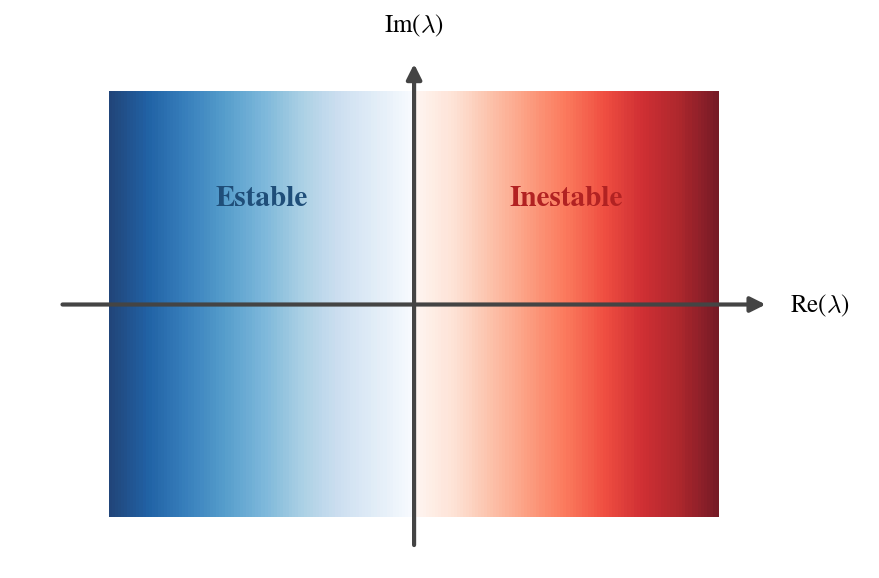

In [ ]:

# 1. Inicializar la figura con alta resolución para impresión (DPI alto)
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

# 2. Crear el degradado de fondo
# Lado izquierdo (Estable - Azul) que se desvanece al acercarse a 0
grid_left = np.tile(np.linspace(1, 0, 100), (100, 1))
ax.imshow(grid_left, cmap='Blues', extent=[-3, 0, -2, 2], alpha=0.9, aspect='auto')

# Lado derecho (Inestable - Rojo) que aparece a partir de 0
grid_right = np.tile(np.linspace(0, 1, 100), (100, 1))
ax.imshow(grid_right, cmap='Reds', extent=[0, 3, -2, 2], alpha=0.9, aspect='auto')

# 3. Dibujar los ejes personalizados con flechas en las puntas
# Eje Horizontal (Real)
ax.annotate('', xy=(3.5, 0), xytext=(-3.5, 0),
            arrowprops=dict(arrowstyle="-|>", color="#444444", lw=2, mutation_scale=15))
# Eje Vertical (Imaginario)
ax.annotate('', xy=(0, 2.3), xytext=(0, -2.3),
            arrowprops=dict(arrowstyle="-|>", color="#444444", lw=2, mutation_scale=15))

# 4. Añadir las etiquetas matemáticas de los ejes
ax.text(3.7, 0, r'Re($\lambda$)', va='center', ha='left', fontsize=12)
ax.text(0, 2.5, r'Im($\lambda$)', va='bottom', ha='center', fontsize=12)

# 5. Añadir los textos "Stable" y "Unstable" con sus respectivos colores
ax.text(-1.5, 1, 'Estable', color='#1f4e79', fontsize=14, ha='center', va='center', weight='bold')
ax.text(1.5, 1, 'Inestable', color='#b22222', fontsize=14, ha='center', va='center', weight='bold')

# 6. Limpieza estética: Ocultar los bordes y marcas por defecto de matplotlib
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Configurar límites estrictos de la vista para que no se corte nada
ax.set_xlim(-4, 4.5)
ax.set_ylim(-2.5, 2.8)

plt.tight_layout()
plt.show()

## Evolución de autovalores

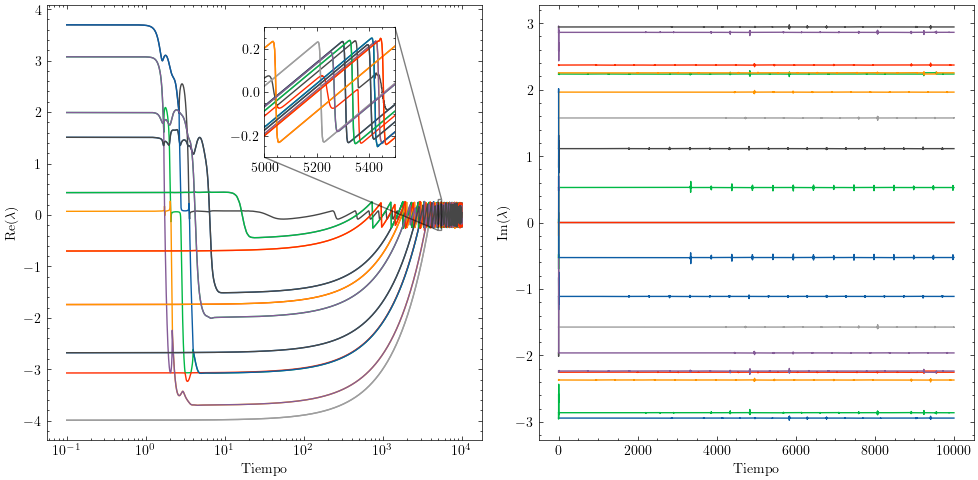

In [ ]:
dim = 20
time = 10000
t_eval = np.logspace(-1, 4, 150000)
alpha = 0.001

rng_X = np.random.default_rng(42)
rng_W = np.random.default_rng(69)

X_0 = rng_X.normal(loc=0, scale=1/np.sqrt(dim), size=dim)
W_0 = rng_W.normal(loc=0, scale=1, size=(dim, dim))

y_0 = np.concatenate([X_0, W_0.flatten()])
solution = solve_ivp(ODE_system, [0, time], y0=y_0, args=[dim, alpha], t_eval=t_eval, method='DOP853')

X = solution.y[:dim, :].transpose()
W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

# eigenvalues = track_eigenvalues(W)
eigenvalues = np.linalg.eigvals(W)
eigenvalues = track_eigenvalues(eigenvalues, weight_real=1, weight_imag=10)

plt.style.use(['science'])

fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].semilogx(t_eval, eigenvalues.real, lw=1, rasterized=True)
ax[1].plot(t_eval, eigenvalues.imag, lw=1, rasterized=True)
ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)

# Inset axes
axins = ax[0].inset_axes([0.5, 0.65, 0.3, 0.3], xlim=[5000, 5500], ylim=[-0.3, 0.3])
axins.plot(t_eval, eigenvalues.real, lw=1)
ax[0].indicate_inset_zoom(axins, edgecolor='black')

# Títulos y texto
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel(r"Re$(\lambda)$")

ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel(r"Im$(\lambda)$")

plt.tight_layout()

plt.savefig("Figures/Evolucion coloreada.pdf")
plt.show()

# W_norm = np.linalg.norm(W, axis=(1, 2))
# X_norm = np.linalg.norm(X, axis=1)

# y = X_norm**2
# y_dotdot = np.gradient(np.gradient(y, t_eval), t_eval)

# plt.plot(y_dotdot, y, 'b.', ms=1)
# plt.show()

# V = 0.5 * W_norm**2 + alpha * (0.5 * X_norm**2 - np.log(X_norm))
# dVdt = (np.trace(W, axis1=1, axis2=2) - np.einsum('ti, tij, tj -> t', X, W, X)/X_norm**2)
# V_dot = np.gradient(V, t_eval)

# plt.plot(t_eval, (V - V.mean())/(V.max()-V.min()), label='Lyapunov function')
# plt.plot(t_eval, (V_dot - V_dot.mean())/(V_dot.max()-V_dot.min()), label=r"$\frac{dV}{dt}$ numérica", alpha=0.8)
# plt.plot(t_eval, (dVdt - dVdt.mean())/(dVdt.max()-dVdt.min()), label=r"$\frac{dV}{dt}$ analítica", alpha=0.8)
# plt.legend()
# plt.show()

# print("X: ", X.shape)
# print("W: ", W.shape)
# WX = np.einsum('tij, tj -> ti', W, X)
# WX_norm = np.linalg.norm(WX, axis=1)
# X_norm = np.linalg.norm(X, axis=1)

# W_spectral_norm = np.linalg.norm(W, ord=2, axis=(1, 2))

# plt.plot(WX_norm, label=r"$|WX|$")
# plt.plot(W_norm * X_norm/2, label=r"$|W||X|$")
# # plt.plot(W_spectral_norm * X_norm, label=r"$\sigma_{max}(W)|X|$")
# plt.legend()
# plt.show()



## Circular Law

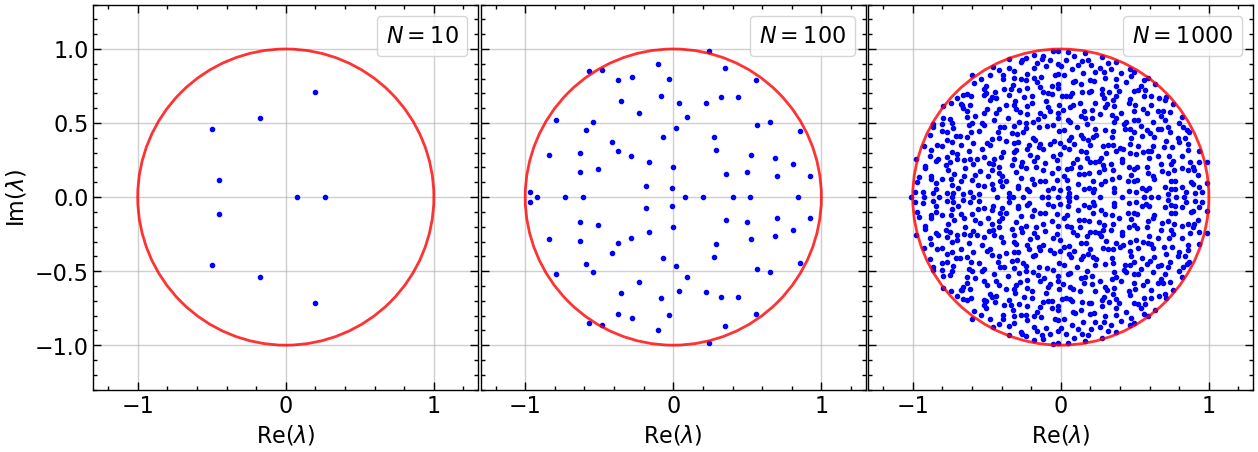

In [ ]:
from matplotlib.patches import Circle
dims = [10, 100, 1000]

matrices = [np.random.standard_normal((dim, dim)) for dim in dims]

autovalores = [np.linalg.eigvals(matrix) for matrix in matrices]

plt.style.use(['science', 'notebook'])

fig, ax = plt.subplots(ncols=3, figsize=(15, 5), sharey=True, gridspec_kw={'wspace': 0})

for i in range(3):
    autovalores[i] = autovalores[i]/np.sqrt(dims[i])
    ax[i].plot(autovalores[i].real, autovalores[i].imag, 'b.', label=fr"$N = {dims[i]}$")
    ax[i].set_aspect('equal')
    ax[i].set_xlabel(r"Re$(\lambda)$")
    circle = Circle([0, 0], 1.0, edgecolor='red', fill=False, linewidth=2, zorder=5, alpha=0.8)
    ax[i].add_patch(circle)
    ax[i].grid(True, alpha=0.6)
    ax[i].set_xlim(-1.3, 1.3)
    ax[i].set_ylim(-1.3, 1.3)
    ax[i].legend(frameon=True, markerscale=0, handletextpad=0, handlelength=0)
    if i > 0:
        ax[i].tick_params(labelleft=False)
ax[0].set_ylabel(r"Im$(\lambda)$")

plt.savefig("Figures/circular law.pdf")
plt.show()

## Excitación de modos

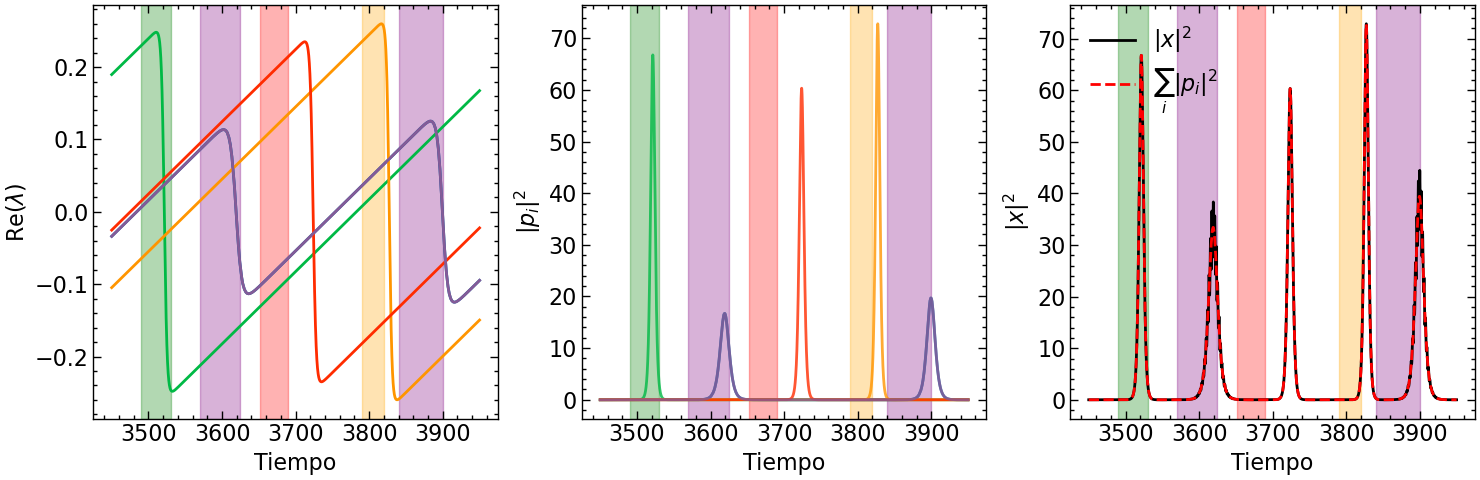

0.11517753699690125


In [4]:
dim = 5
rng_W = np.random.default_rng(42)
rng_X = np.random.default_rng(42)
time = 4000
alpha = 0.001
t_eval = np.linspace(3450, 3950, 10000)

W_0 = rng_W.standard_normal((dim, dim))
X_0= rng_X.standard_normal(dim)

y_0 = np.concatenate([X_0, W_0.flatten()])
solution = solve_ivp(ODE_system, [0, time], y0=y_0, args=[dim, alpha], t_eval=t_eval, method='DOP853')

X = solution.y[:dim, :].transpose()
W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

X_norm = np.linalg.norm(X, axis=1)**2

eigenvalues, eigenvectors = np.linalg.eig(W)

tracked_evals, r_tracked_evecs = track_eigen_inertia(eigenvalues, eigenvectors)

l_tracked_evecs = np.linalg.inv(r_tracked_evecs)

projections = np.abs(np.einsum('tij,tj->ti', l_tracked_evecs, X))**2

cross_terms = X_norm - np.sum(projections, axis=1)

plt.style.use(['science', 'notebook'])
plt.close()
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

ax[0].plot(t_eval, tracked_evals.real)
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel(r"Re$(\lambda)$")
ax[0].axvspan(xmin=3490, xmax=3530, color='green', alpha=0.3)
ax[0].axvspan(xmin=3570, xmax=3625, color='purple', alpha=0.3)
ax[0].axvspan(xmin=3652, xmax=3690, color='red', alpha=0.3)
ax[0].axvspan(xmin=3790, xmax=3820, color='orange', alpha=0.3)
ax[0].axvspan(xmin=3840, xmax=3900, color='purple', alpha=0.3)

for i in range(dim):
    ax[1].plot(t_eval, projections[:,i], alpha=0.8)
ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel(r"$|p_i|^2$")
ax[1].axvspan(xmin=3490, xmax=3530, color='green', alpha=0.3)
ax[1].axvspan(xmin=3570, xmax=3625, color='purple', alpha=0.3)
ax[1].axvspan(xmin=3652, xmax=3690, color='red', alpha=0.3)
ax[1].axvspan(xmin=3790, xmax=3820, color='orange', alpha=0.3)
ax[1].axvspan(xmin=3840, xmax=3900, color='purple', alpha=0.3)


ax[2].set_xlabel("Tiempo")
ax[2].plot(t_eval, X_norm, c='k', label=r"$|x|^2$")
ax[2].plot(t_eval, np.sum(projections, axis=1), c='r', ls='--', label=r"$\sum_i|p_i|^2$")
ax[2].set_ylabel(r"$|x|^2$")
ax[2].axvspan(xmin=3490, xmax=3530, color='green', alpha=0.3)
ax[2].axvspan(xmin=3570, xmax=3625, color='purple', alpha=0.3)
ax[2].axvspan(xmin=3652, xmax=3690, color='red', alpha=0.3)
ax[2].axvspan(xmin=3790, xmax=3820, color='orange', alpha=0.3)
ax[2].axvspan(xmin=3840, xmax=3900, color='purple', alpha=0.3)
ax[2].legend(loc='upper left')

plt.tight_layout()
plt.savefig("Figures/Picos.pdf")
plt.show()

error = np.linalg.norm(r_tracked_evecs[-1].conj().T @ r_tracked_evecs[-1] - np.eye(dim)) / (dim * (dim-1))

print(error)


## Estudio de autovalores

In [ ]:
%matplotlib widget
dim = 100
rng_W = np.random.default_rng(42)
rng_X = np.random.default_rng(42)
time = 500
alpha = 0.001
t_eval = np.linspace(0, time, 100000)

W_0 = rng_W.standard_normal((dim, dim)) 
W_0 = (W_0.T + W_0)/2.0

X_0= rng_X.standard_normal(dim)

y_0 = np.concatenate([X_0, W_0.flatten()])
solution = solve_ivp(ODE_system, [0, time], y0=y_0, args=[dim, alpha], t_eval=t_eval, method='DOP853')

X = solution.y[:dim, :].transpose()
W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

X_norm = np.linalg.norm(X, axis=1)**2

eigenvalues = np.linalg.eigvals(W)

tracked_evals = track_eigenvalues(eigenvalues)

plt.style.use(['science', 'notebook'])
plt.close()

plt.plot(t_eval, tracked_evals.real)
plt.show()

## Excitación de modos para dimensión alta

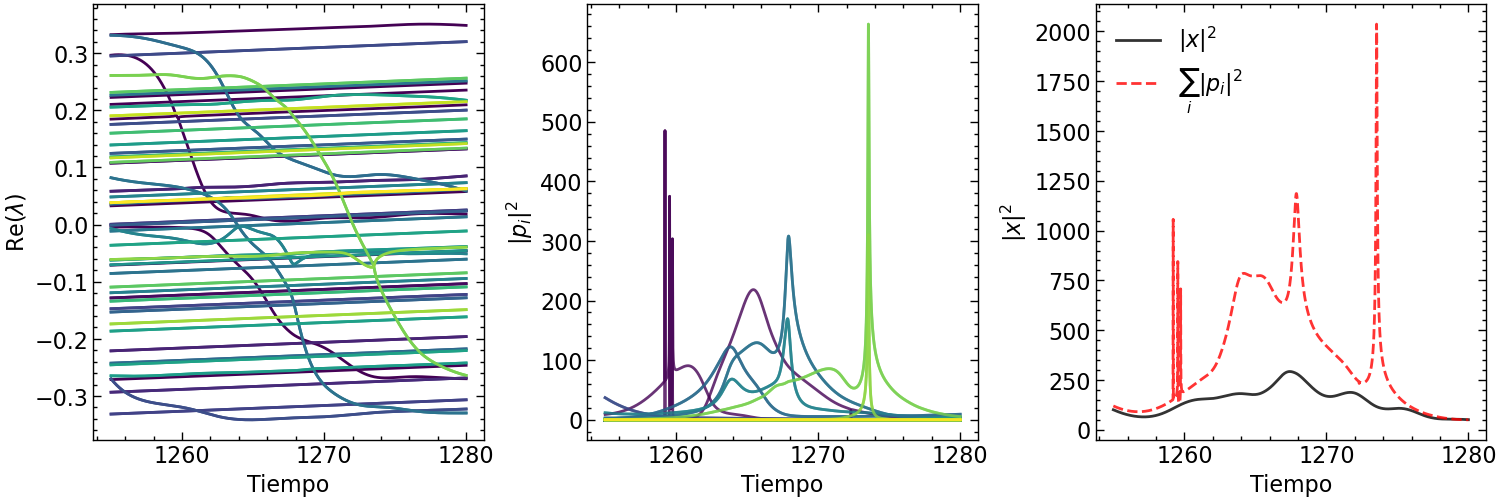

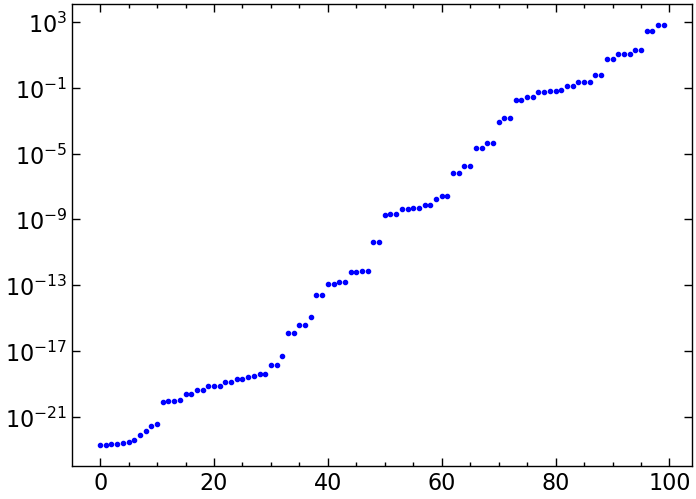

In [5]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

dim = 100
rng_W = np.random.default_rng(42)
rng_X = np.random.default_rng(42)
time = 1280
alpha = 0.001
t_eval = np.linspace(1255, time, 2000)

W_0 = rng_W.standard_normal((dim, dim)) / np.sqrt(dim)
X_0= rng_X.standard_normal(dim)

y_0 = np.concatenate([X_0, W_0.flatten()])
solution = solve_ivp(ODE_system, [0, time], y0=y_0, args=[dim, alpha], t_eval=t_eval, method='DOP853')

X = solution.y[:dim, :].transpose()
W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

X_norm = np.linalg.norm(X, axis=1)**2

eigenvalues, eigenvectors = np.linalg.eig(W)

tracked_evals, r_tracked_evecs = track_eigen_inertia(eigenvalues, eigenvectors)

l_tracked_evecs = np.linalg.inv(r_tracked_evecs)

projections = np.einsum('tij,tj->ti', l_tracked_evecs, X)

projection_norm = np.linalg.norm(projections, axis=1)**2

cross_terms = X_norm - projection_norm

plt.style.use(['science', 'notebook'])
plt.close()
fig, ax = plt.subplots(ncols=3, figsize=(15, 5), sharex=True, layout="constrained")

# Coloreamos los autovalores por su parte imaginaria

abs_imag_part = np.abs(np.mean(tracked_evals.imag, axis=0))
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=abs_imag_part.min(), vmax=abs_imag_part.max())
colores = cmap(norm(abs_imag_part))

for i in range(dim):
    ax[0].plot(t_eval, tracked_evals[:, i].real, color=colores[i])
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel(r"Re$(\lambda)$")

for i in range(dim):
    ax[1].plot(t_eval, np.abs(projections[:,i])**2, alpha=0.8, color=colores[i])
ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel(r"$|p_i|^2$")

ax[2].set_xlabel("Tiempo")
ax[2].plot(t_eval, X_norm, c='k', label=r"$|x|^2$", alpha=0.8)
ax[2].plot(t_eval, projection_norm, c='r', ls='--', label=r"$\sum_i|p_i|^2$", alpha=0.8)
ax[2].set_ylabel(r"$|x|^2$")

# sm = cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax.tolist(), label="Parte imaginaria")
plt.legend(loc='upper left')

plt.savefig("Figures/Picos_acoplados.pdf")
plt.show()

plt.close()
plt.semilogy(np.sort(np.abs(projections[1482])**2), 'b.')
plt.show()


## Modelo de Hopfield

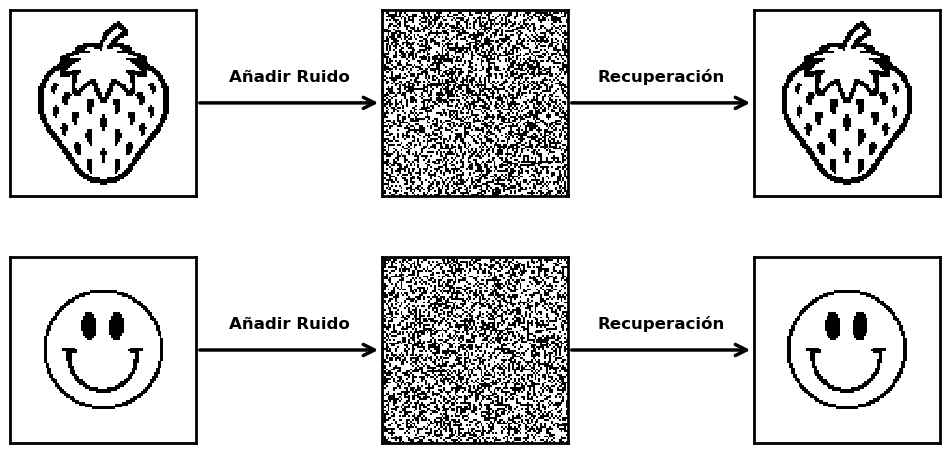

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from PIL import Image
from matplotlib.patches import ConnectionPatch

def preparar_vector_hopfield(ruta_imagen, tamano=32, umbral=127, invertir=False):
    """
    Convierte una imagen PNG/JPG en una matriz cuadrada de 1s y -1s.
    
    :param ruta_imagen: Ruta del archivo (ej. 'numero3.png')
    :param tamano: El ancho/alto de la matriz cuadrada (ej. 32 para una matriz de 32x32)
    :param umbral: Valor (0-255) para decidir qué es "blanco" y qué es "negro"
    :param invertir: Si es True, el fondo blanco se vuelve -1 y el dibujo negro se vuelve 1
    """
    # 1. Abrir la imagen y convertirla a escala de grises ('L')
    img = Image.open(ruta_imagen).convert('L')
    
    # 2. Redimensionar a una matriz cuadrada (tamano x tamano)
    img = img.resize((tamano, tamano))
    
    # 3. Convertir a un array de NumPy
    img_array = np.array(img)
    
    # 4. Binarizar a 1 y -1 basado en el umbral
    if invertir:
        # Píxeles oscuros (< umbral) se vuelven 1, claros se vuelven -1
        matriz_hopfield = np.where(img_array < umbral, 1, -1)
    else:
        # Píxeles claros (> umbral) se vuelven 1, oscuros se vuelven -1
        matriz_hopfield = np.where(img_array > umbral, 1, -1)
        
    return matriz_hopfield.flatten()


def add_annotated_arrow(ax_start, ax_end, text):
    """
    Dibuja una flecha entre dos ejes y coloca un texto sobre ella.
    """
    # 1. Definir los puntos de conexión. 'axes fraction' usa coordenadas de 0 a 1 dentro del eje.
    # Conectamos desde el centro del borde derecho del eje inicial (1.02, 0.5)
    # hasta el centro del borde izquierdo del eje final (-0.02, 0.5)
    xy_start = (1.02, 0.5) 
    xy_end = (-0.02, 0.5)
    
    # 2. Crear la flecha usando ConnectionPatch
    arrow = ConnectionPatch(xyA=xy_start, xyB=xy_end, coordsA="axes fraction", coordsB="axes fraction",
                            axesA=ax_start, axesB=ax_end,
                            arrowstyle="->", color="black", linewidth=2.5, mutation_scale=20)
    # mutation_scale hace la punta de la flecha más grande y visible
    ax_end.add_artist(arrow) # Se añade a uno de los ejes, no importa cuál

    # 3. Colocar el texto sobre la flecha. 
    # Calculamos el punto medio entre los dos ejes en coordenadas de figura para posicionar el texto.
    bbox_start = ax_start.get_position()
    bbox_end = ax_end.get_position()
    mid_x = (bbox_start.x1 + bbox_end.x0) / 2
    mid_y = (bbox_start.y0 + bbox_start.y1) / 2
    
    # Añadir el texto con fig.text
    fig.text(mid_x, mid_y + 0.03, text, ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

L = 100

vector_fresa = preparar_vector_hopfield("fresa.png", tamano=L, invertir=True)
vector_cara = preparar_vector_hopfield("smiley.jpg", tamano=L, invertir=True)

X_0_fresa = np.sign(5 * np.random.standard_normal(L * L) + vector_fresa)
X_0_cara = np.sign(5 * np.random.standard_normal(L * L) + vector_cara)

W = 0.5 * (np.outer(vector_cara, vector_cara) + np.outer(vector_fresa, vector_fresa))

X_fresa = np.sign(W @ X_0_fresa)
X_cara= np.sign(W @ X_0_cara)

fig, ax = plt.subplots(2, 3, figsize=(12, 6), gridspec_kw={'wspace': 1.0, 'hspace': 0.15})


data = [[np.reshape(vector_fresa, (L, L)), np.reshape(X_0_fresa, (L, L)), np.reshape(X_fresa, (L, L))], 
        [np.reshape(vector_cara, (L, L)), np.reshape(X_0_cara, (L, L)), np.reshape(X_cara, (L, L))]]
for i in range(2):
    for j in range(3):
        ax[i, j].imshow(data[i][j], cmap='Grays', vmin=-1, vmax=1, interpolation='none')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        for spine in ax[i, j].spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(2)

# --- APLICAR LAS ANOTACIONES ---
# Fila 1 (Fresa)
add_annotated_arrow(ax[0, 0], ax[0, 1], "Añadir Ruido")
add_annotated_arrow(ax[0, 1], ax[0, 2], "Recuperación")

# Fila 2 (Cara)
add_annotated_arrow(ax[1, 0], ax[1, 1], "Añadir Ruido")
add_annotated_arrow(ax[1, 1], ax[1, 2], "Recuperación")

plt.savefig("Figures/Hopfield.pdf")
plt.show()




## Distribución de autovalores en la colectividad de Ginibre

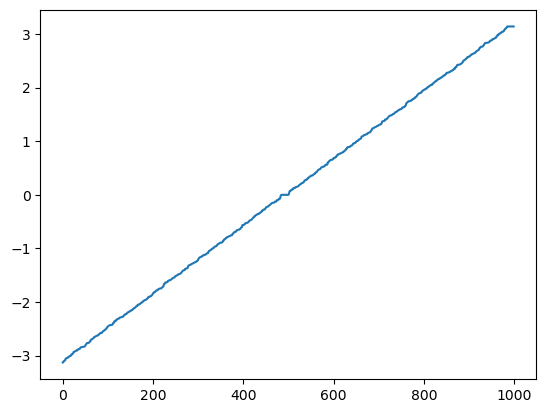

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000

W = np.random.normal(0, 1/np.sqrt(N), (N, N))

eigenvalues = np.linalg.eigvals(W)

phases = np.angle(eigenvalues)

plt.plot(np.sort(phases))

plt.show()

## $|x|^2$ para diferentes tamaños del sistema


--- Iniciando N = 1 ---
Paso 40000 / 400000
Paso 80000 / 400000
Paso 120000 / 400000
Paso 160000 / 400000
Paso 200000 / 400000
Paso 240000 / 400000
Paso 280000 / 400000
Paso 320000 / 400000
Paso 360000 / 400000
N = 1 simulado, procesando gráfica...

--- Iniciando N = 10 ---
Paso 40000 / 400000
Paso 80000 / 400000
Paso 120000 / 400000
Paso 160000 / 400000
Paso 200000 / 400000
Paso 240000 / 400000
Paso 280000 / 400000
Paso 320000 / 400000
Paso 360000 / 400000
N = 10 simulado, procesando gráfica...

--- Iniciando N = 100 ---
Paso 40000 / 400000
Paso 80000 / 400000
Paso 120000 / 400000
Paso 160000 / 400000
Paso 200000 / 400000
Paso 240000 / 400000
Paso 280000 / 400000
Paso 320000 / 400000
Paso 360000 / 400000
N = 100 simulado, procesando gráfica...


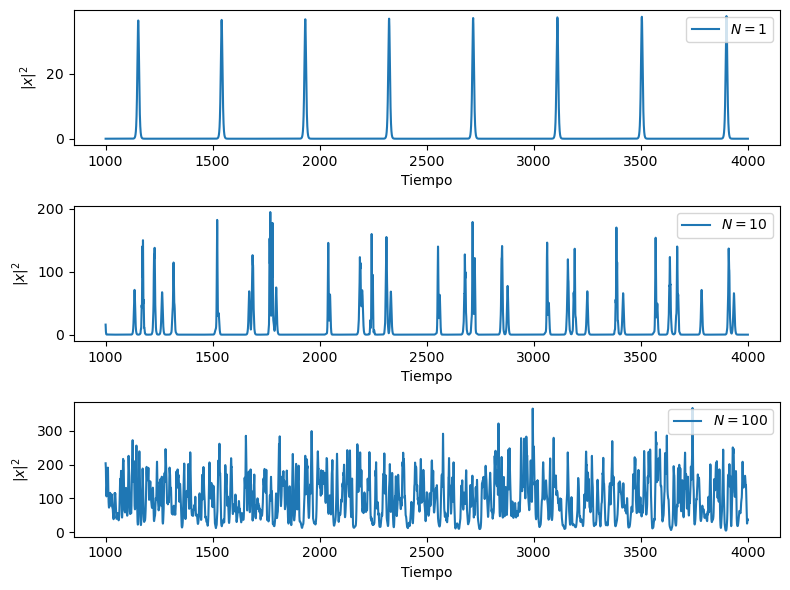

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

@njit(fastmath=True)
def antiHebbian(X_0, W_0, alpha, dt, steps):
    dim = X_0.shape[0]
    X = np.zeros((steps, dim))
    X[0] = X_0
    W = np.copy(W_0) # Usar copy para no modificar el original por error
    I = np.eye(dim)
    
    # Pre-reservamos memoria para las matrices auxiliares para no hacerlo en el bucle
    dWdt = np.zeros((dim, dim))
    outer_X = np.zeros((dim, dim))

    for t in range(1, steps):
        if (10 * t) % steps == 0:
            print("Paso", t, "/", steps)
            
        # Seguro contra explosión numérica (NaN)
        if np.isnan(X[t-1, 0]) or np.isnan(W[0, 0]):
            print("¡Alerta! Inestabilidad numérica detectada. Valores = NaN.")
            break

        # 1. Calculamos dXdt
        dXdt = W @ X[t-1]
        
        # 2. Calculamos el outer product a mano o usando la función, pero 
        # asignándolo eficientemente si es posible. (Numba maneja np.outer, 
        # pero para optimizarlo del todo, evitamos operaciones encadenadas complejas)
        outer_X = np.outer(X[t-1], X[t-1])
        dWdt = alpha * (I - outer_X)

        # 3. Actualizamos X y W
        X[t] = X[t-1] + dt * dXdt
        W = W + dt * dWdt

    return X

# PARÁMETROS REDUCIDOS PARA PRUEBAS (Te recomiendo subir esto poco a poco)
dims = [1, 10, 100] # Cambiado 1000 por 50 para que veas que termina
time = 4000
t_0 = 1000
alpha = 0.001
dt = 0.01
steps = int(time/dt)
s_0 = int(t_0/dt)
eval_steps = int((time - t_0)/dt)
t_eval = np.linspace(t_0, time, eval_steps)

fig, ax = plt.subplots(len(dims), figsize=(8, 6))
if len(dims) == 1:
    ax = [ax] # Asegurar que sea iterable si solo hay 1 dimensión

for i, N in enumerate(dims):
    print(f"\n--- Iniciando N = {N} ---")
    W_0 = np.random.normal(0, 1/np.sqrt(N), (N, N))
    X_0 = np.random.normal(0, 1/np.sqrt(N), N)

    X = antiHebbian(X_0, W_0, alpha, dt, steps)
    print(f"N = {N} simulado, procesando gráfica...")
    
    ax[i].plot(t_eval, np.linalg.norm(X[s_0:steps], axis=1)**2, label=fr"$N=${N}")
    ax[i].set_ylabel(r"$|x|^2$")
    ax[i].set_xlabel("Tiempo")
    ax[i].legend(loc='upper right')
plt.tight_layout()
plt.savefig("Figures/Norma X diferentes dimensiones.pdf")
plt.show()

## Atractor unidimensional

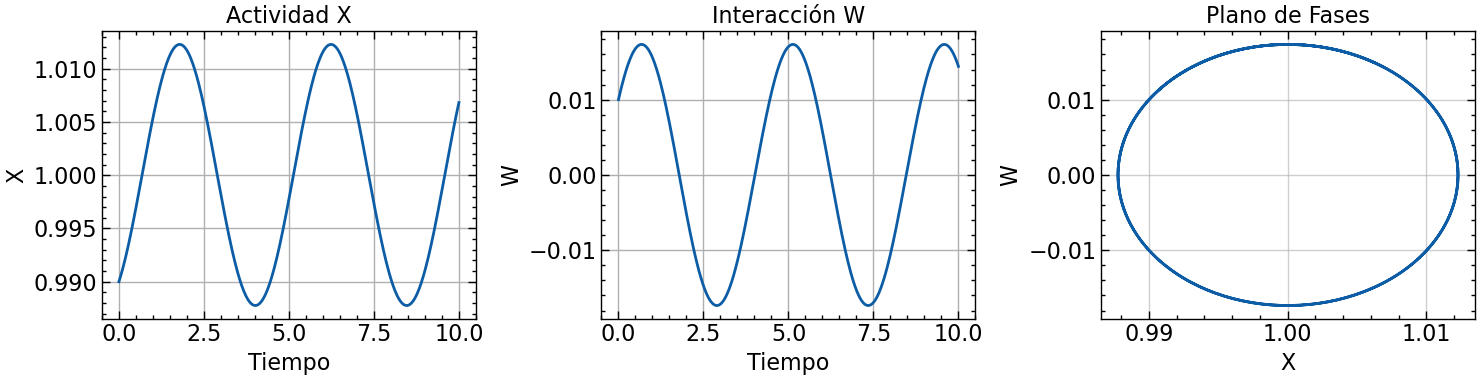

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
time = 10
dt = 0.02  # En métodos simplécticos puedes usar un dt fijo razonable
steps = int(time / dt)
alpha = 1

# Condiciones iniciales originales
X_0 = 0.99
W_0 = 0.01

# Transformación a variables canónicas (q, p)
q = np.zeros(steps)
p = np.zeros(steps)
q[0] = np.log(X_0)
p[0] = W_0

# Bucle del Integrador Simpléctico (Leapfrog / Verlet)
for t in range(0, steps - 1):
    # 1. Medio paso para el momento p
    p_half = p[t] + 0.5 * dt * (alpha * (1.0 - np.exp(2.0 * q[t])))
    
    # 2. Paso completo para la posición q usando el p intermedio
    q[t+1] = q[t] + dt * p_half
    
    # 3. Segundo medio paso para el momento p usando el q nuevo
    p[t+1] = p_half + 0.5 * dt * (alpha * (1.0 - np.exp(2.0 * q[t+1])))

# Deshacemos el cambio de variable para volver a la física original
X = np.exp(q)
W = p

# Calculamos el Hamiltoniano para verificar la conservación
H = 0.5 * W**2 + 0.5 * alpha * X**2 - alpha * np.log(np.abs(X))

# --- Gráficas ---
t_axis = np.linspace(0, time, steps)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(t_axis, X)
plt.title("Actividad X")
plt.xlabel("Tiempo")
plt.ylabel("X")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(t_axis, W)
plt.title("Interacción W")
plt.xlabel("Tiempo")
plt.ylabel("W")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(X, W)
plt.title("Plano de Fases")
plt.xlabel("X")
plt.ylabel("W")
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

## Estudio de autovectores

Paso 40000 / 400000
Paso 80000 / 400000
Paso 120000 / 400000
Paso 160000 / 400000
Paso 200000 / 400000
Paso 240000 / 400000
Paso 280000 / 400000
Paso 320000 / 400000
Paso 360000 / 400000
Calculando autovalores...
Autovalores calculados
Ordenando autovalores
Autovalores ordenados


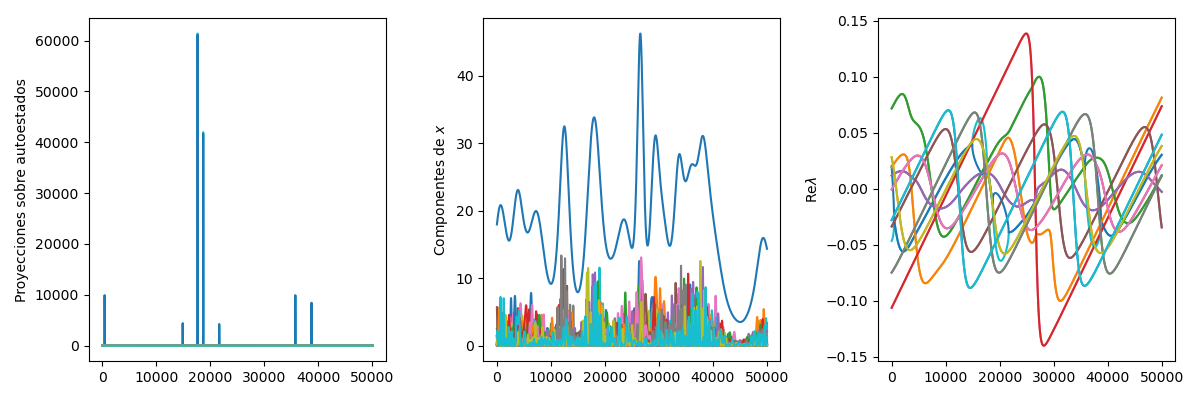

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

@njit(fastmath=True)
def antiHebbian(X_0, W_0, alpha, dt, steps):
    dim = X_0.shape[0]
    X = np.zeros((steps, dim))
    W = np.zeros((steps, dim, dim))
    X[0] = X_0
    W[0] = W_0
    I = np.eye(dim)
    
    # Pre-reservamos memoria para las matrices auxiliares para no hacerlo en el bucle
    dWdt = np.zeros((dim, dim))
    outer_X = np.zeros((dim, dim))

    for t in range(1, steps):
        if (10 * t) % steps == 0:
            print("Paso", t, "/", steps)
            
        # Seguro contra explosión numérica (NaN)
        if np.isnan(X[t-1, 0]) or np.isnan(W[t-1, 0, 0]):
            print("¡Alerta! Inestabilidad numérica detectada. Valores = NaN.")
            break

        # 1. Calculamos dXdt
        dXdt = W[t-1] @ X[t-1]
        
        # 2. Calculamos el outer product a mano o usando la función, pero 
        # asignándolo eficientemente si es posible. (Numba maneja np.outer, 
        # pero para optimizarlo del todo, evitamos operaciones encadenadas complejas)
        outer_X = np.outer(X[t-1], X[t-1])
        dWdt = alpha * (I - outer_X)

        # 3. Actualizamos X y W
        X[t] = X[t-1] + dt * dXdt
        W[t] = W[t-1] + dt * dWdt

    return X, W

def track_eigen_inertia(all_evals, all_evecs):
    """
    Ordena autovalores y autovectores a lo largo del tiempo basándose EXCLUSIVAMENTE
    en la inercia (predicción lineal) de la trayectoria de los autovalores.
    
    all_evals: array (T, N) de autovalores complejos.
    all_evecs: array (T, N, N) de autovectores complejos.
    """
    T, N = all_evals.shape
    tracked_evals = np.zeros((T, N), dtype=np.complex128)
    tracked_evecs = np.zeros((T, N, N), dtype=np.complex128)
    
    if T == 0:
        return tracked_evals, tracked_evecs
        
    # --- Paso t=0: Ordenar por parte imaginaria ---
    idx_0 = np.argsort(all_evals[0].imag)
    tracked_evals[0] = all_evals[0][idx_0]
    tracked_evecs[0] = all_evecs[0][:, idx_0]
    
    if T == 1:
        return tracked_evals, tracked_evecs

    # --- Paso t=1: Distancia pura (sin inercia aún) ---
    curr_evals = all_evals[1]
    prev_evals = tracked_evals[0]
    
    cost_matrix = np.abs(prev_evals[:, None] - curr_evals[None, :])
    _, col_ind = linear_sum_assignment(cost_matrix)
    
    tracked_evals[1] = curr_evals[col_ind]
    tracked_evecs[1] = all_evecs[1][:, col_ind]

    # --- Pasos t >= 2: Inercia / Predicción Lineal ---
    for t in range(2, T):
        curr_evals = all_evals[t]
        
        # 1. Calcular la velocidad (delta) del paso anterior
        velocidad = tracked_evals[t-1] - tracked_evals[t-2]
        
        # 2. Predecir la posición esperada en el paso actual
        prediccion = tracked_evals[t-1] + velocidad
        
        # 3. Matriz de costo: Distancia entre la PREDICCIÓN y los valores ACTUALES
        cost_matrix = np.abs(prediccion[:, None] - curr_evals[None, :])
        
        # 4. Asignación óptima con el algoritmo húngaro
        _, col_ind = linear_sum_assignment(cost_matrix)        
        
        # 5. Guardar los resultados ordenados
        tracked_evals[t] = curr_evals[col_ind]
        tracked_evecs[t, :, :] = all_evecs[t][:, col_ind]
        
    return tracked_evals, tracked_evecs

dim = 20
time = 4000
t_0 = 3500
alpha = 0.001
dt = 0.01
steps = int(time/dt)
s_0 = int(t_0/dt)
eval_steps = int((time - t_0)/dt)
t_eval = np.linspace(t_0, time, eval_steps)

W_0 = np.random.normal(0, 1/np.sqrt(dim), (dim, dim))
W_0 = (W_0 - np.transpose(W_0))/2

X_0 = np.random.normal(0, 1/np.sqrt(dim), dim)

full_X, full_W = antiHebbian(X_0, W_0, alpha, dt, steps)

# Tomamos solo los datos de 2000 para adelante
W = full_W[s_0:]
X = full_X[s_0:]

print("Calculando autovalores...")
eigenvalues, eigenvectors = np.linalg.eig(W)
print("Autovalores calculados")
print("Ordenando autovalores")
tracked_evals, r_tracked_evecs = track_eigen_inertia(eigenvalues, eigenvectors)
print("Autovalores ordenados")


l_tracked_evecs = np.linalg.inv(r_tracked_evecs)
projections = np.einsum('tij,tj->ti', l_tracked_evecs, X)
plt.close()
fig, ax = plt.subplots(ncols=3, figsize=(12,4))
ax[0].plot(np.abs(projections)**2)
ax[0].set_ylabel("Proyecciones sobre autoestados")
ax[1].plot(X**2)
ax[1].plot(np.linalg.norm(X, axis=1)**2)
ax[1].set_ylabel(r"Componentes de $x$")
ax[2].plot(tracked_evals.real)
ax[2].set_ylabel(r"Re$\lambda$")

plt.tight_layout()
plt.show()

## Medida de ortogonalidad

Ajuste para los autovectores
a: -0.4071676078772824
b: -0.17098275764983187
Ajuste para los vectores random
a: -0.5076677555191932
b: -0.18838531686388124


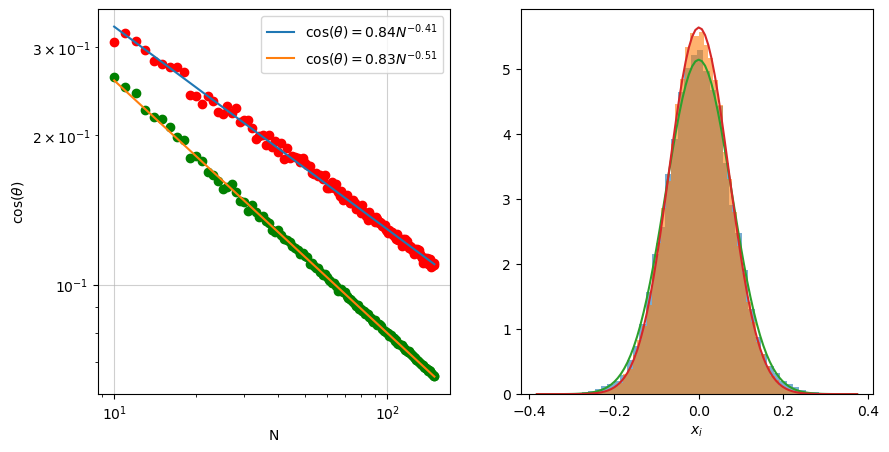

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.linalg import eig

def off_diag_mean(mat):
    """Calcula la media del valor absoluto de los elementos fuera de la diagonal."""
    N = mat.shape[0]
    P = mat.conj().T @ mat
    return np.mean(np.abs(P[~np.eye(N, dtype=bool)]))

dims = np.arange(10, 150)
n_tests = 10
rng = np.random.default_rng()

cos_medio = []
cos_random_medio = []

# --- PARTE 1: Ajuste de decaimiento ---
for N in dims:
    c_eig, c_rand = 0, 0
    for _ in range(n_tests):
        # 1. Autovectores
        _, V = eig(rng.standard_normal((N, N)))
        c_eig += off_diag_mean(V)

        # 2. Vectores aleatorios (Complejos y normalizados por columnas de golpe)
        R = rng.standard_normal((N, N)) + 1j * rng.standard_normal((N, N))
        R /= np.linalg.norm(R, axis=0) 
        c_rand += off_diag_mean(R)

    cos_medio.append(c_eig / n_tests)
    cos_random_medio.append(c_rand / n_tests)

cos_medio = np.array(cos_medio)
cos_random_medio = np.array(cos_random_medio)

# --- AJUSTES POLINÓMICOS ---
(a, log_b), _ = np.polyfit(np.log(dims), np.log(cos_medio), 1)
(a_r, log_b_r), _ = np.polyfit(np.log(dims), np.log(cos_random_medio), 1)
b, b_r = np.exp(log_b), np.exp(log_b_r)

print(f"Ajuste Autovectores: a = {a:.3f}, b = {b:.3f}")
print(f"Ajuste Random:       a = {a_r:.3f}, b = {b_r:.3f}")

# --- PARTE 2: Histograma ---
n_test_hist, dim = 5, 100
eig_vals, rand_vals = [], []

for _ in range(n_test_hist):
    _, V = eig(rng.standard_normal((dim, dim)))
    eig_vals.append(V.real.flatten())

    R = rng.standard_normal((dim, dim)) + 1j * rng.standard_normal((dim, dim))
    R /= np.linalg.norm(R, axis=0)
    rand_vals.append(R.real.flatten())

# Concatenamos las listas de arrays en un solo array 1D
eig_vals = np.concatenate(eig_vals)
rand_vals = np.concatenate(rand_vals)


# --- GRÁFICAS ---
plt.figure(figsize=(12, 5))

# Subplot 1: Log-Log
plt.subplot(1, 2, 1)
plt.loglog(dims, cos_medio, 'ro', alpha=0.6)
plt.loglog(dims, cos_random_medio, 'go', alpha=0.6)
plt.loglog(dims, b * dims**a, 'r-', label=fr"Autovec: $\cos(\theta) = {b:.2f}N^{{{a:.2f}}}$")
plt.loglog(dims, b_r * dims**a_r, 'g-', label=fr"Random: $\cos(\theta) = {b_r:.2f}N^{{{a_r:.2f}}}$")
plt.xlabel("N")
plt.ylabel(r"$\cos(\theta)$")
plt.grid(True, alpha=0.6)
plt.legend()

# Subplot 2: Histogramas
plt.subplot(1, 2, 2)
plt.hist(eig_vals, bins=50, density=True, alpha=0.6, color='red', label='Autovectores')
plt.hist(rand_vals, bins=50, density=True, alpha=0.6, color='green', label='Random')

x_range = np.linspace(min(eig_vals.min(), rand_vals.min()), max(eig_vals.max(), rand_vals.max()), 100)
plt.plot(x_range, norm.pdf(x_range, np.mean(eig_vals), np.std(eig_vals)), 'r-')
plt.plot(x_range, norm.pdf(x_range, np.mean(rand_vals), np.std(rand_vals)), 'g-')

plt.xlabel(r"$x_i$")
plt.ylabel("Densidad")
plt.legend()

plt.tight_layout()
plt.show()

## Segunda medida de ortogonalidad

--- RESULTADOS DEL AJUSTE ---
Grados de libertad (nu): 2.68  <-- ¡Si está cerca de 2, la varianza es infinita!
Centro (media):          0.0105
Parámetro de escala:     0.4045 <-- Esta es tu verdadera 'regla' para medir, no la std


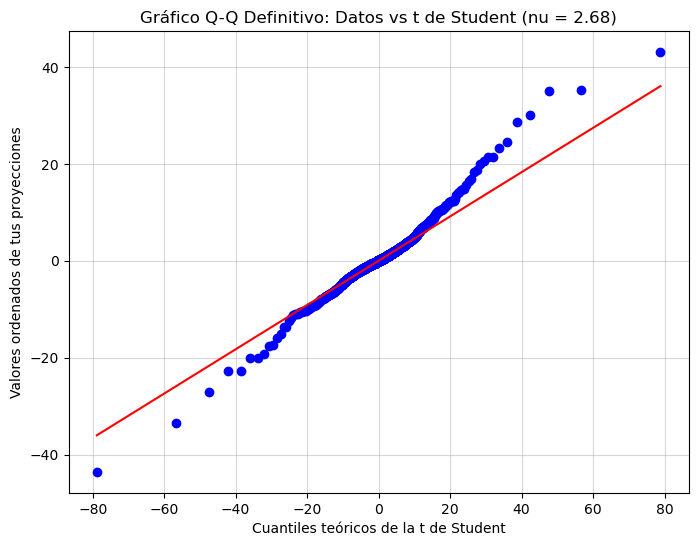

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from scipy.stats import norm
from scipy.stats import kurtosis
import scipy.stats as stats

dim = 10
n_test = 10000

rng = np.random.default_rng()

X = rng.standard_normal(dim)

X = X / np.linalg.norm(X)

projection_norm = np.zeros(n_test * dim)

for i in range(n_test):
    matrix = rng.standard_normal((dim, dim))

    _, r_eigenvectors = np.linalg.eig(matrix)
    l_eigenvectors = np.linalg.inv(r_eigenvectors)

    projections = l_eigenvectors @ X
    projection_norm[i*dim : (i+1)*dim] = projections.real

# 1. Ajustamos tus datos a una t de Student para encontrar los parámetros reales
# df = grados de libertad (nu), loc = centro, scale = dispersión
df_fit, loc_fit, scale_fit = stats.t.fit(projection_norm)

print("--- RESULTADOS DEL AJUSTE ---")
print(f"Grados de libertad (nu): {df_fit:.2f}  <-- ¡Si está cerca de 2, la varianza es infinita!")
print(f"Centro (media):          {loc_fit:.4f}")
print(f"Parámetro de escala:     {scale_fit:.4f} <-- Esta es tu verdadera 'regla' para medir, no la std")

# 2. Gráfico Q-Q contra la t de Student con los grados de libertad encontrados
plt.figure(figsize=(8, 6))
stats.probplot(projection_norm, dist=stats.t(df=df_fit), plot=plt)

plt.title(f"Gráfico Q-Q Definitivo: Datos vs t de Student (nu = {df_fit:.2f})")
plt.xlabel("Cuantiles teóricos de la t de Student")
plt.ylabel("Valores ordenados de tus proyecciones")
plt.grid(True, alpha=0.5)
plt.show()

## Tercera medida de ortogonalidad

Exponente (todos):  0.7057119618909645
Exponente (reales):  0.3655305988060303
Exponente (complejos):  0.8314607458691237


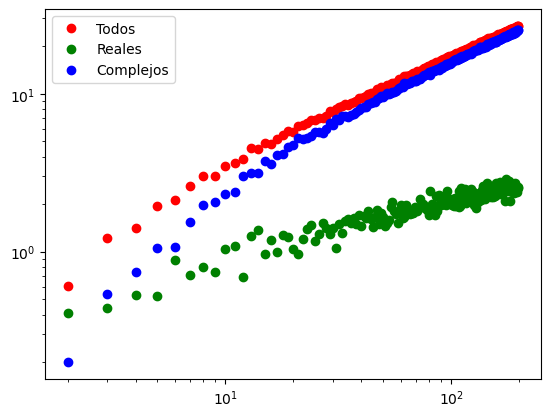

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dims = np.arange(2, 200)
n_tests = 20
errors = np.zeros_like(dims, dtype=np.float64)
real_errors = np.zeros_like(dims, dtype=np.float64)
complex_errors = np.zeros_like(dims, dtype=np.float64)
rng = np.random.default_rng()

for i, N in enumerate(dims):
    for test in range(n_tests):

        matrix = rng.standard_normal((N, N))
        eigenvalues, V = np.linalg.eig(matrix)

        real_mask = np.where(np.abs(eigenvalues.imag) < 1e-5, True, False)
        complex_mask = ~real_mask
        real_V = V[:, real_mask]
        complex_V = V[:, complex_mask]
        N_real = np.shape(real_V)[1]
        N_complex = N - N_real

        real_errors[i] += np.linalg.norm(real_V.conj().T @ real_V - np.eye(N_real))
        complex_errors[i] += np.linalg.norm(complex_V.conj().T @ complex_V - np.eye(N_complex))
        errors[i] += np.linalg.norm(V.conj().T @ V - np.eye(N))


    errors[i] = errors[i]/n_tests
    real_errors[i] = real_errors[i]/n_tests
    complex_errors[i] = complex_errors[i]/n_tests

a, _ = np.polyfit(np.log(dims), np.log(errors), 1)
a_real, _ = np.polyfit(np.log(dims), np.log(real_errors), 1)
a_complex, _ = np.polyfit(np.log(dims), np.log(complex_errors), 1)

print("Exponente (todos): ", a)
print("Exponente (reales): ", a_real)
print("Exponente (complejos): ", a_complex)
plt.loglog(dims, errors, 'ro', label="Todos")
plt.loglog(dims, real_errors, 'go', label="Reales")
plt.loglog(dims, complex_errors, 'bo', label="Complejos")

plt.legend()
plt.show() 

## Cuarta medida de ortogonalidad

Exponente (todos):  0.34231642549290153


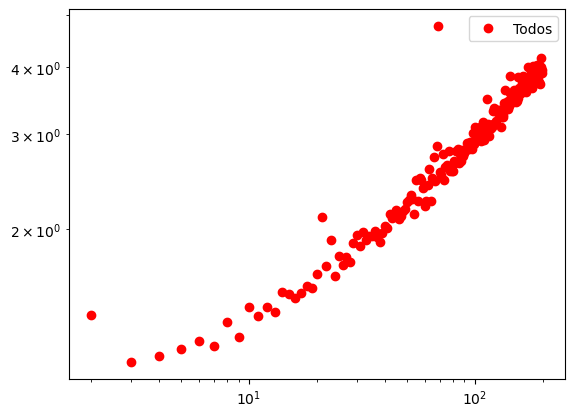

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dims = np.arange(2, 200)
n_tests = 50
conditions = np.zeros_like(dims, dtype=np.float64)
rng = np.random.default_rng()

for i, N in enumerate(dims):
    for test in range(n_tests):

        M = rng.standard_normal((N, N))
        A = (M.T - M)/2.0 + 0.2 * rng.standard_normal((N, N))

        _, V = np.linalg.eig(A)

        V_inv = np.linalg.inv(V)


        conditions[i] += np.linalg.norm(V) * np.linalg.norm(V_inv) / N


    conditions[i] = conditions[i]/n_tests

a, _ = np.polyfit(np.log(dims), np.log(conditions), deg=1)

print("Exponente (todos): ", a)

plt.close()
plt.loglog(dims, conditions, 'ro', label="Todos")
plt.legend()
plt.show() 

## Medida del caos

3415
Exponente de Lyapunov:  0.14005199643570718


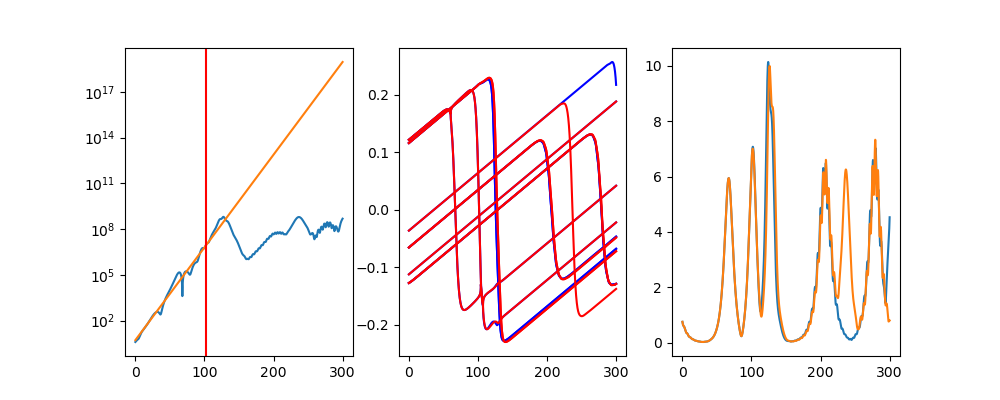

In [139]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

def Simular(X_0, W_0, alpha, time_span):
    dim = X_0.shape[0]
    steps = time_span.shape[0]

    y_0 = np.concatenate([X_0, W_0.flatten()])
    solution = solve_ivp(ODE_system, [0, time_span[-1]], y0=y_0, args=[dim, alpha], t_eval=time_span, method='DOP853')

    X = solution.y[:dim, :].transpose()
    W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

    return X, W

dim = 10
alpha = 0.001
rng = np.random.default_rng()
t_init = 2.0 / alpha
t_0 = 0
time = 300
epsilon = 1e-8
steps = 10000
dt = (time - t_0) / steps
t_eval = np.linspace(t_0, time, steps)

W_0 = rng.standard_normal((dim, dim)) / np.sqrt(dim)

X_0 = rng.standard_normal(dim)

X, W = Simular(X_0, W_0, alpha, np.array([t_init]))

X_0_npert = X[0]
X_0_pert = X[0] + epsilon * rng.standard_normal(dim)

X_npert, W_npert = Simular(X_0_npert, W[0], alpha, t_eval)
X_pert, W_pert = Simular(X_0_pert, W[0], alpha, t_eval)

delta = np.linalg.norm(X_pert - X_npert, axis=1) / epsilon
eigenvalues_npert = np.linalg.eigvals(W_npert)
eigenvalues_pert = np.linalg.eigvals(W_pert)

tracked_evals_npert = track_eigenvalues(eigenvalues_npert)
tracked_evals_pert = track_eigenvalues(eigenvalues_pert)

condicion = delta > 1e7

indice = np.argmax(condicion)

print(indice)

a, b = np.polyfit(t_eval[:indice], np.log(delta[:indice]), deg=1)

print("Exponente de Lyapunov: ", a)

plt.close()
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.semilogy(t_eval, delta)
plt.semilogy(t_eval, np.exp(a * t_eval + b))
plt.axvline(t_eval[indice], color='red')

plt.subplot(1, 3, 2)
plt.plot(t_eval, tracked_evals_npert.real, color='blue')
plt.plot(t_eval, tracked_evals_pert.real, color='red')

plt.subplot(1, 3, 3)
plt.plot(t_eval, np.linalg.norm(X_npert, axis=1))
plt.plot(t_eval, np.linalg.norm(X_pert, axis=1))
plt.show()


## Choque de autovalores

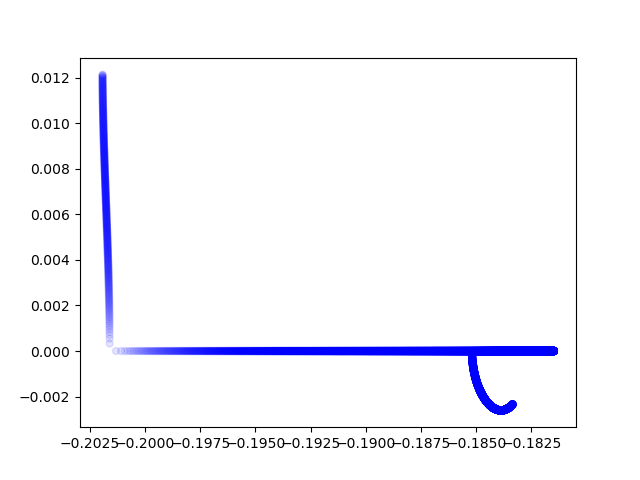

In [168]:
import numpy as np
import matplotlib.pyplot as plt

def Simular(X_0, W_0, alpha, time_span):
    dim = X_0.shape[0]
    steps = time_span.shape[0]

    y_0 = np.concatenate([X_0, W_0.flatten()])
    solution = solve_ivp(ODE_system, [0, time_span[-1]], y0=y_0, args=[dim, alpha], t_eval=time_span, method='DOP853')

    X = solution.y[:dim, :].transpose()
    W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

    return X, W

rng = np.random.default_rng(42)
dim = 20
alpha = 0.001
t_eval = np.linspace(1877, 1897, 10000)
X_0 = rng.standard_normal(dim) / np.sqrt(dim)
W_0 = rng.standard_normal((dim, dim)) / np.sqrt(dim)

X, W = Simular(X_0, W_0, alpha, t_eval)

eigenvalues = np.linalg.eigvals(W)

tracked_evals = track_eigenvalues(eigenvalues)

plt.close()
# for i in range(dim):
#     plt.plot(t_eval, tracked_evals[:, i].real, label=f"N = {i}")

# plt.plot(t_eval, tracked_evals[:, 12].real, label=f"N = {12}")
# plt.plot(t_eval, tracked_evals[:, 7].real, label=f"N = {7}")

eval1 = tracked_evals[:, 12]
eval2 = tracked_evals[:, 7]
# 1. Creamos un vector de transparencias (de 0.05 a 1.0) del mismo largo que tus datos
alphas = np.linspace(0.05, 1.0, len(eval1))

# 2. Graficamos todo de un solo golpe usando 'alpha=alphas'
plt.scatter(eval1.real, eval1.imag, color='blue', alpha=alphas, s=25)
# plt.scatter(eval2.real, eval2.imag, color='red', alpha=alphas, s=25)

plt.show()



## Almacenamiento de una memoria

Integración completada
Integración completada
Integración completada
Integración completada


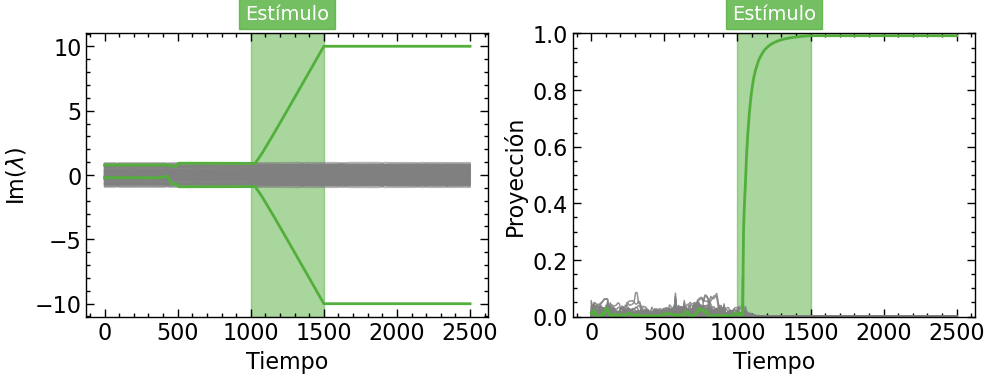

In [ ]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def learning_system(t, y, dim, alpha, A, I_dim):
    X = y[:dim]
    W = y[dim:].reshape((dim, dim))

    # I_dim ya viene precalculada para evitar alocación de memoria constante
    dWdt = alpha * (I_dim - np.outer(X, X) + A)
    dXdt = W @ X

    return np.concatenate([dXdt, dWdt.flatten()])

def Simular_learning(X_0, W_0, alpha, time_span, A=0):
    dim = X_0.shape[0]
    I_dim = np.eye(dim) # Precalculamos la identidad aquí

    y_0 = np.concatenate([X_0, W_0.flatten()])
    solution = solve_ivp(fun=learning_system, 
                         t_span=[0, time_span[-1]], 
                         y0=y_0, 
                         args=[dim, alpha, A, I_dim], # Pasamos I_dim
                         t_eval=time_span, 
                         method='DOP853')

    if solution.success:
        X = solution.y[:dim, :].transpose()
        W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)
        print("Integración completada")
        return X, W
    else:
        print("No se pudo integrar correctamente")
        return None, None

# OPTIMIZADA: Ahora recibe Q_2 precalculado
def cos_proyeccion_hiperespacio_opt(x, y, Q_2):
    plano_1 = np.column_stack((x, y))
    Q_1, _ = np.linalg.qr(plano_1)
    
    # Q_2 ya viene listo de fuera
    M = Q_1.T @ Q_2
    
    cos_angulos_principales = np.linalg.svd(M, compute_uv=False)
    cos_angulos_principales = np.clip(cos_angulos_principales, -1.0, 1.0)
    
    return np.prod(cos_angulos_principales)

# --- Configuración Inicial ---
dim = 100
alpha = 0.001
rho = 20
rng = np.random.default_rng()
W_0 = rng.normal(0, 1 / np.sqrt(dim), (dim, dim))
X_0 = rng.normal(0, 1 / np.sqrt(dim), dim)
t_eval_init = np.array([1.5 / alpha])
t_eval_pre = np.linspace(0, 1000, 100)
t_eval_learning = np.linspace(0, 500, 1000)
t_eval_post = np.linspace(0, 1000, 100)

u = rng.standard_normal(dim)
u = u / np.linalg.norm(u)

v = rng.standard_normal(dim)
v = v - np.dot(u, v) * u
v = v / np.linalg.norm(v)

# PRECALCULO CRÍTICO: Como u y v ya son ortonormales, su column_stack ya es la matriz Q_2
Q_2_precalculada = np.column_stack((u, v))

A = rho * (np.outer(u, v) - np.outer(v, u))

# --- Simulaciones ---
X_init, W_init = Simular_learning(X_0, W_0, alpha, t_eval_init)
X_pre, W_pre = Simular_learning(X_init[-1], W_init[-1], alpha, t_eval_pre)
X_learning, W_learning = Simular_learning(X_pre[-1], W_pre[-1], alpha, t_eval_learning, A)
X_post, W_post = Simular_learning(X_learning[-1], W_learning[-1], alpha, t_eval_post)

# --- Análisis espectral ---
total_W = np.concatenate([W_pre, W_learning, W_post])
total_evals, total_evecs = np.linalg.eig(total_W)

# Asumo que esta función existe en tu entorno
tracked_evals, tracked_evecs = track_eigen_inertia(total_evals, total_evecs)

min_idx = np.argmin(tracked_evals[-1].imag)
max_idx = np.argmax(tracked_evals[-1].imag)

total_time = np.concatenate([t_eval_pre, t_eval_learning + t_eval_pre[-1], t_eval_post + t_eval_learning[-1] + t_eval_pre[-1]])
total_steps = total_time.shape[0]

# --- Bucle de Proyecciones Optimizado ---
all_projections = np.zeros((total_steps, dim))

for t in range(total_steps):
    for i in range(dim):
        x_real = tracked_evecs[t, :, i].real
        y_imag = tracked_evecs[t, :, i].imag
        
        # Pasamos la matriz Q_2 precalculada ahorrando miles de operaciones QR
        all_projections[t, i] = cos_proyeccion_hiperespacio_opt(x_real, y_imag, Q_2_precalculada)

# --- Gráficos ---
plt.close()
plt.style.use(['science', 'notebook'])
plt.figure(figsize=(10, 4))

# Subplot 1
plt.subplot(1, 2, 1)
plt.plot(total_time, np.delete(tracked_evals.imag, [min_idx, max_idx], axis=1), color='gray', alpha=0.6, lw=1)
plt.plot(total_time, tracked_evals[:, [min_idx, max_idx]].imag, color='#53AF3C', alpha=1)
plt.axvspan(t_eval_pre[-1], t_eval_pre[-1] + t_eval_learning[-1], alpha=0.5, color='#53AF3C')
plt.xlabel("Tiempo")
plt.ylabel(r"Im$(\lambda)$")
plt.text(0.5, 1.05, "Estímulo", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))

# Subplot 2
plt.subplot(1, 2, 2)
plt.plot(total_time, np.delete(all_projections, [max_idx, min_idx], axis=1), color='gray', lw=1, alpha=0.6)
plt.plot(total_time, all_projections[:, max_idx], color='#53AF3C')
plt.axvspan(t_eval_pre[-1], t_eval_pre[-1] + t_eval_learning[-1], alpha=0.5, color='#53AF3C')
plt.text(0.5, 1.05, "Estímulo", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))
plt.ylim(0.0, 1.0)
plt.xlabel("Tiempo")
plt.ylabel("Proyección")
plt.tight_layout()
plt.savefig("Figures/visualizacion estimulo.pdf") 
plt.show()

## Almacenamiento de varias memorias

Integración completada
Integración completada
Integración completada
Integración completada
Integración completada
Integración completada


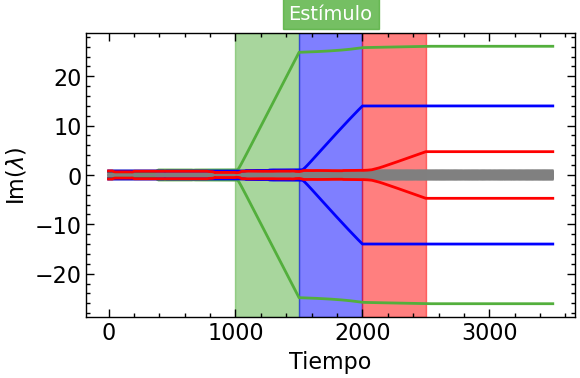

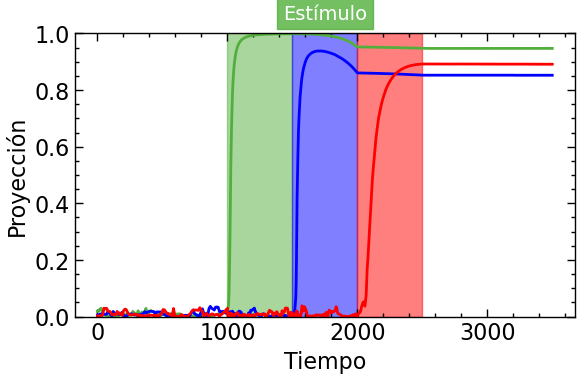

In [16]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def learning_system(t, y, dim, alpha, A, I_dim):
    X = y[:dim]
    W = y[dim:].reshape((dim, dim))

    # I_dim ya viene precalculada para evitar alocación de memoria constante
    dWdt = alpha * (I_dim - np.outer(X, X) + A)
    dXdt = W @ X

    return np.concatenate([dXdt, dWdt.flatten()])

def Simular_learning(X_0, W_0, alpha, time_span, A=0):
    dim = X_0.shape[0]
    I_dim = np.eye(dim) # Precalculamos la identidad aquí

    y_0 = np.concatenate([X_0, W_0.flatten()])
    solution = solve_ivp(fun=learning_system, 
                         t_span=[0, time_span[-1]], 
                         y0=y_0, 
                         args=[dim, alpha, A, I_dim], # Pasamos I_dim
                         t_eval=time_span, 
                         method='DOP853')

    if solution.success:
        X = solution.y[:dim, :].transpose()
        W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)
        print("Integración completada")
        return X, W
    else:
        print("No se pudo integrar correctamente")
        return None, None

def cos_proyeccion_hiperespacio_opt(x, y, Q_2):
    plano_1 = np.column_stack((x, y))
    Q_1, _ = np.linalg.qr(plano_1)
    
    # Q_2 ya viene listo de fuera
    M = Q_1.T @ Q_2
    
    cos_angulos_principales = np.linalg.svd(M, compute_uv=False)
    cos_angulos_principales = np.clip(cos_angulos_principales, -1.0, 1.0)
    
    return np.prod(cos_angulos_principales)

# --- Configuración Inicial ---
dim = 100
alpha = 0.001
rho = np.array([50, 30, 10])
rng = np.random.default_rng()
W_0 = rng.normal(0, 1 / np.sqrt(dim), (dim, dim))
X_0 = rng.normal(0, 1 / np.sqrt(dim), dim)
t_eval_init = np.array([1.5 / alpha])
t_eval_pre = np.linspace(0, 1000, 100)
t_eval_learning = np.array([np.linspace(0, 500, 1000), np.linspace(0, 500, 1000), np.linspace(0, 500, 1000)])
t_eval_post = np.linspace(0, 1000, 100)

u = [rng.standard_normal(dim) for i in range(3)]
u = [u[i] / np.linalg.norm(u[i]) for i in range(3)]

v = [rng.standard_normal(dim) for i in range(3)]
v = [v[i] - np.dot(u[i], v[i]) * u[i] for i in range(3)]
v = [v[i] / np.linalg.norm(v[i]) for i in range(3)]

# PRECALCULO CRÍTICO: Como u y v ya son ortonormales, su column_stack ya es la matriz Q_2
Q_2_precalculada = [np.column_stack((u[i], v[i])) for i in range(3)]

A = [rho[i] * (np.outer(u[i], v[i]) - np.outer(v[i], u[i])) for i in range(3)]

# --- Simulaciones ---
X_init, W_init = Simular_learning(X_0, W_0, alpha, t_eval_init)
X_pre, W_pre = Simular_learning(X_init[-1], W_init[-1], alpha, t_eval_pre)
X_learning1, W_learning1 = Simular_learning(X_pre[-1], W_pre[-1], alpha, t_eval_learning[0], A[0])
X_learning2, W_learning2 = Simular_learning(X_learning1[-1], W_learning1[-1], alpha, t_eval_learning[1], A[1])
X_learning3, W_learning3 = Simular_learning(X_learning2[-1], W_learning2[-1], alpha, t_eval_learning[2], A[2])
X_post, W_post = Simular_learning(X_learning3[-1], W_learning3[-1], alpha, t_eval_post)

# --- Análisis espectral ---
total_W = np.concatenate([W_pre, W_learning1, W_learning2, W_learning3, W_post])
total_evals, total_evecs = np.linalg.eig(total_W)

# Asumo que esta función existe en tu entorno
tracked_evals, tracked_evecs = track_eigen_inertia(total_evals, total_evecs)

# Tomamos los índices de los tres autovalores con menor parte imaginaria
min_idx = np.argsort(tracked_evals.imag[-1])[:3]
max_idx = np.argsort(-tracked_evals.imag[-1])[:3]
selected_idx = np.concatenate([min_idx, max_idx])

total_time = np.concatenate([t_eval_pre, 
                             t_eval_learning[0] + t_eval_pre[-1], 
                             t_eval_learning[1] + t_eval_pre[-1] + t_eval_learning[0][-1], 
                             t_eval_learning[2] + t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1], 
                             t_eval_post + t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1] + t_eval_learning[2][-1]])

total_steps = total_time.shape[0]

# --- Bucle de Proyecciones Optimizado ---
all_projections = np.zeros((3, total_steps))

for t in range(total_steps):
    for i, m in enumerate(max_idx):
        x_real = tracked_evecs[t, :, m].real
        y_imag = tracked_evecs[t, :, m].imag
        for m in range(3):
            all_projections[i, t] = cos_proyeccion_hiperespacio_opt(x_real, y_imag, Q_2_precalculada[i])

# --- Gráficos ---
plt.close()
plt.style.use(['science', 'notebook'])
plt.figure(figsize=(6, 4))

# Plot 1
plt.plot(total_time, np.delete(tracked_evals.imag, selected_idx, axis=1), color='gray', alpha=0.6, lw=1)
plt.plot(total_time, tracked_evals[:, [min_idx[0], max_idx[0]]].imag, color='#53AF3C', alpha=1)
plt.plot(total_time, tracked_evals[:, [min_idx[1], max_idx[1]]].imag, color='blue', alpha=1)
plt.plot(total_time, tracked_evals[:, [min_idx[2], max_idx[2]]].imag, color='red', alpha=1)
plt.axvspan(t_eval_pre[-1], t_eval_pre[-1] + t_eval_learning[0][-1], alpha=0.5, color='#53AF3C')
plt.axvspan(t_eval_pre[-1] + t_eval_learning[0][-1], t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1], alpha=0.5, color='blue')
plt.axvspan(t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1], t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1] + t_eval_learning[2][-1], alpha=0.5, color='red')
plt.xlabel("Tiempo")
plt.ylabel(r"Im$(\lambda)$")
plt.text(0.5, 1.05, "Estímulo", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))
plt.tight_layout()
plt.savefig("Figures/memorias antisimetricas.pdf")
plt.show()

# Subplot 2
plt.figure(figsize=(6, 4))
plt.plot(total_time, all_projections[0,:], color='#53AF3C')
plt.plot(total_time, all_projections[1,:], color='blue')
plt.plot(total_time, all_projections[2,:], color='red')
plt.axvspan(t_eval_pre[-1], t_eval_pre[-1] + t_eval_learning[0][-1], alpha=0.5, color='#53AF3C')
plt.axvspan(t_eval_pre[-1] + t_eval_learning[0][-1], t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1], alpha=0.5, color='blue')
plt.axvspan(t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1], t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1] + t_eval_learning[2][-1], alpha=0.5, color='red')
plt.text(0.5, 1.05, "Estímulo", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))
plt.ylim(0.0, 1.0)
plt.xlabel("Tiempo")
plt.ylabel("Proyección")
plt.tight_layout()
plt.savefig("Figures/proyecciones antisimetricas.pdf")
plt.show()

## Almacenamiento varias memorias solapadas

Integración completada
Integración completada
Integración completada
Integración completada
Integración completada
Integración completada


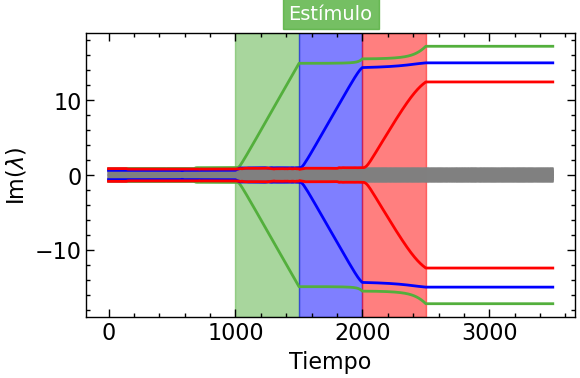

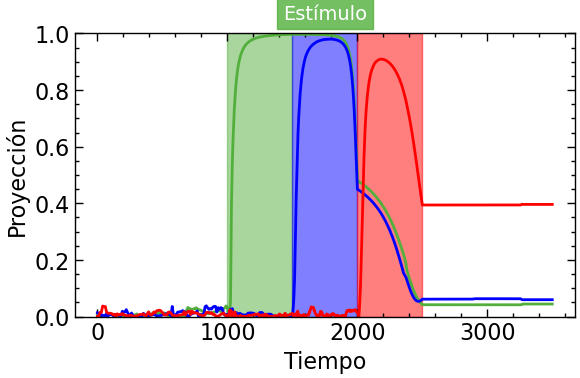

In [17]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def learning_system(t, y, dim, alpha, A, I_dim):
    X = y[:dim]
    W = y[dim:].reshape((dim, dim))

    # I_dim ya viene precalculada para evitar alocación de memoria constante
    dWdt = alpha * (I_dim - np.outer(X, X) + A)
    dXdt = W @ X

    return np.concatenate([dXdt, dWdt.flatten()])

def Simular_learning(X_0, W_0, alpha, time_span, A=0):
    dim = X_0.shape[0]
    I_dim = np.eye(dim) # Precalculamos la identidad aquí

    y_0 = np.concatenate([X_0, W_0.flatten()])
    solution = solve_ivp(fun=learning_system, 
                         t_span=[0, time_span[-1]], 
                         y0=y_0, 
                         args=[dim, alpha, A, I_dim], # Pasamos I_dim
                         t_eval=time_span, 
                         method='DOP853')

    if solution.success:
        X = solution.y[:dim, :].transpose()
        W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)
        print("Integración completada")
        return X, W
    else:
        print("No se pudo integrar correctamente")
        return None, None

def cos_proyeccion_hiperespacio_opt(x, y, Q_2):
    plano_1 = np.column_stack((x, y))
    Q_1, _ = np.linalg.qr(plano_1)
    
    # Q_2 ya viene listo de fuera
    M = Q_1.T @ Q_2
    
    cos_angulos_principales = np.linalg.svd(M, compute_uv=False)
    cos_angulos_principales = np.clip(cos_angulos_principales, -1.0, 1.0)
    
    return np.prod(cos_angulos_principales)

# --- Configuración Inicial ---
dim = 100
alpha = 0.001
rho = np.array([30, 30, 30])
rng = np.random.default_rng()
W_0 = rng.normal(0, 1 / np.sqrt(dim), (dim, dim))
X_0 = rng.normal(0, 1 / np.sqrt(dim), dim)
t_eval_init = np.array([1.5 / alpha])
t_eval_pre = np.linspace(0, 1000, 100)
t_eval_learning = np.array([np.linspace(0, 500, 1000), np.linspace(0, 500, 1000), np.linspace(0, 500, 1000)])
t_eval_post = np.linspace(0, 1000, 100)

u = [rng.standard_normal(dim) for i in range(3)]
u = [u[i] / np.linalg.norm(u[i]) for i in range(3)]

v = [rng.standard_normal(dim) for i in range(3)]
v = [v[i] - np.dot(u[i], v[i]) * u[i] for i in range(3)]
v = [v[i] / np.linalg.norm(v[i]) for i in range(3)]

# PRECALCULO CRÍTICO: Como u y v ya son ortonormales, su column_stack ya es la matriz Q_2
Q_2_precalculada = [np.column_stack((u[i], v[i])) for i in range(3)]

A = [rho[i] * (np.outer(u[i], v[i]) - np.outer(v[i], u[i])) for i in range(3)]

# --- Simulaciones ---
X_init, W_init = Simular_learning(X_0, W_0, alpha, t_eval_init)
X_pre, W_pre = Simular_learning(X_init[-1], W_init[-1], alpha, t_eval_pre)
X_learning1, W_learning1 = Simular_learning(X_pre[-1], W_pre[-1], alpha, t_eval_learning[0], A[0])
X_learning2, W_learning2 = Simular_learning(X_learning1[-1], W_learning1[-1], alpha, t_eval_learning[1], A[1])
X_learning3, W_learning3 = Simular_learning(X_learning2[-1], W_learning2[-1], alpha, t_eval_learning[2], A[2])
X_post, W_post = Simular_learning(X_learning3[-1], W_learning3[-1], alpha, t_eval_post)

# --- Análisis espectral ---
total_W = np.concatenate([W_pre, W_learning1, W_learning2, W_learning3, W_post])
total_evals, total_evecs = np.linalg.eig(total_W)

# Asumo que esta función existe en tu entorno
tracked_evals, tracked_evecs = track_eigen_inertia(total_evals, total_evecs)

# Tomamos los índices de los tres autovalores con menor parte imaginaria
min_idx = np.argsort(tracked_evals.imag[-1])[:3]
max_idx = np.argsort(-tracked_evals.imag[-1])[:3]
selected_idx = np.concatenate([min_idx, max_idx])

total_time = np.concatenate([t_eval_pre, 
                             t_eval_learning[0] + t_eval_pre[-1], 
                             t_eval_learning[1] + t_eval_pre[-1] + t_eval_learning[0][-1], 
                             t_eval_learning[2] + t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1], 
                             t_eval_post + t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1] + t_eval_learning[2][-1]])

total_steps = total_time.shape[0]

# --- Bucle de Proyecciones Optimizado ---
all_projections = np.zeros((3, total_steps))

for t in range(total_steps):
    for i, m in enumerate(max_idx):
        x_real = tracked_evecs[t, :, m].real
        y_imag = tracked_evecs[t, :, m].imag
        for m in range(3):
            all_projections[i, t] = cos_proyeccion_hiperespacio_opt(x_real, y_imag, Q_2_precalculada[i])

# --- Gráficos ---
plt.close()
plt.style.use(['science', 'notebook'])
plt.figure(figsize=(6, 4))

# Subplot 1
plt.plot(total_time, np.delete(tracked_evals.imag, selected_idx, axis=1), color='gray', alpha=0.6, lw=1)
plt.plot(total_time, tracked_evals[:, [min_idx[0], max_idx[0]]].imag, color='#53AF3C', alpha=1)
plt.plot(total_time, tracked_evals[:, [min_idx[1], max_idx[1]]].imag, color='blue', alpha=1)
plt.plot(total_time, tracked_evals[:, [min_idx[2], max_idx[2]]].imag, color='red', alpha=1)
plt.axvspan(t_eval_pre[-1], t_eval_pre[-1] + t_eval_learning[0][-1], alpha=0.5, color='#53AF3C')
plt.axvspan(t_eval_pre[-1] + t_eval_learning[0][-1], t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1], alpha=0.5, color='blue')
plt.axvspan(t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1], t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1] + t_eval_learning[2][-1], alpha=0.5, color='red')
plt.xlabel("Tiempo")
plt.ylabel(r"Im$(\lambda)$")
plt.text(0.5, 1.05, "Estímulo", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))
plt.tight_layout()
plt.savefig("Figures/memorias solapadas.pdf")
plt.show()

# Subplot 2
plt.figure(figsize=(6, 4))
plt.plot(total_time, all_projections[0,:], color='#53AF3C')
plt.plot(total_time, all_projections[1,:], color='blue')
plt.plot(total_time, all_projections[2,:], color='red')
plt.axvspan(t_eval_pre[-1], t_eval_pre[-1] + t_eval_learning[0][-1], alpha=0.5, color='#53AF3C')
plt.axvspan(t_eval_pre[-1] + t_eval_learning[0][-1], t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1], alpha=0.5, color='blue')
plt.axvspan(t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1], t_eval_pre[-1] + t_eval_learning[0][-1] + t_eval_learning[1][-1] + t_eval_learning[2][-1], alpha=0.5, color='red')
plt.text(0.5, 1.05, "Estímulo", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))
plt.ylim(0.0, 1.0)
plt.xlabel("Tiempo")
plt.ylabel("Proyección")
plt.tight_layout()
plt.savefig("Figures/proyecciones solapadas.pdf")
plt.show()

## Rotaciones en planos

Finalizado alpha =  1.0
Finalizado alpha =  0.4832930238571753
Finalizado alpha =  0.23357214690901226
Finalizado alpha =  0.11288378916846892
Finalizado alpha =  0.0545559478116852
Finalizado alpha =  0.026366508987303583
Finalizado alpha =  0.012742749857031341
Finalizado alpha =  0.006158482110660267
Finalizado alpha =  0.002976351441631319
Finalizado alpha =  0.0014384498882876629
Finalizado alpha =  0.0006951927961775605
Finalizado alpha =  0.00033598182862837843
Finalizado alpha =  0.00016237767391887227
Finalizado alpha =  7.847599703514623e-05
Finalizado alpha =  3.792690190732254e-05
Finalizado alpha =  1.8329807108324375e-05
Finalizado alpha =  8.858667904100832e-06
Finalizado alpha =  4.281332398719396e-06
Finalizado alpha =  2.06913808111479e-06
Finalizado alpha =  1e-06
a =  0.4704626393107492
b =  2.3703047295546957


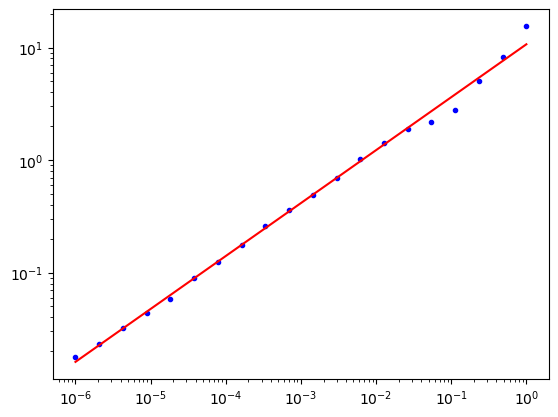

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def ODE_system(t, y, dim, alpha):
    X = y[:dim]
    W = y[dim:].reshape((dim, dim))

    dim = np.shape(X)[0]
    dWdt = alpha * (np.eye(dim) - np.outer(X, X))
    dXdt = W @ X

    return np.concatenate([dXdt, dWdt.flatten()])

def Simular(X_0, W_0, alpha, time_span):
    dim = X_0.shape[0]
    steps = time_span.shape[0]

    y_0 = np.concatenate([X_0, W_0.flatten()])
    solution = solve_ivp(ODE_system, [0, time_span[-1]], y0=y_0, args=[dim, alpha], t_eval=time_span, method='DOP853')

    X = solution.y[:dim, :].transpose()
    W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

    return X, W

dim = 10

rng = np.random.default_rng()

# u = rng.standard_normal(dim)
# u = u / np.linalg.norm(u)

# v = rng.standard_normal(dim)
# v = v - np.dot(u, v) * u
# v = v / np.linalg.norm(v)

# n = rng.standard_normal(dim)
# n = n / np.linalg.norm(n)

W_0 = rng.standard_normal((dim, dim)) / np.sqrt(dim)

X_0 = rng.standard_normal(dim) / np.sqrt(dim)

alpha = np.logspace(0, -6, 20)

amplitude = np.zeros_like(alpha)
std = np.zeros_like(alpha)
for i in range(20):
    t_eval = np.linspace(1.5 / alpha[i] + 200, 2.0 / alpha[i] + 400, 1000)

    X, W = Simular(X_0, W_0, alpha[i], t_eval)
    evals = np.linalg.eigvals(W)
    tracked_evals = track_eigenvalues(evals)

    amplitude[i] = np.mean(np.max(tracked_evals.real, axis=0) - np.min(tracked_evals.real, axis=0))
    std[i] = np.std(np.max(tracked_evals.real, axis=0) - np.min(tracked_evals.real, axis=0))

    print("Finalizado alpha = ", alpha[i])

# evals, evecs = np.linalg.eig(W)

# tracked_evals, r_tracked_evecs = track_eigen_inertia(evals, evecs)

# l_tracked_evecs = np.linalg.inv(r_tracked_evecs)

# max_evec = l_tracked_evecs[:, max_idx, :]
# min_evec = l_tracked_evecs[:, min_idx, :]

a, b = np.polyfit(np.log(alpha), np.log(amplitude), deg=1)
print("a = ", a)
print("b = ", b)

plt.loglog(alpha, amplitude, 'b.')
plt.plot(alpha, np.exp(b) * alpha ** a, 'r-')
plt.show()

# plt.plot(t_eval, tracked_evals.real)
# plt.axhline(y=3, color='k', ls='--')
# plt.axhline(y=-3, color='k', ls='--')
# plt.show()

# plt.plot(t_eval, np.delete(tracked_evals.imag, [min_idx, max_idx], axis=1))
# plt.plot(t_eval, tracked_evals[:, [min_idx, max_idx]].imag, 'k--')
# plt.show()

# X_norm = np.linalg.norm(X, axis=1)

# p_evec1 = np.abs(np.einsum('ti,ti->t', max_evec, X)) / X_norm
# p_evec2 = np.abs(np.einsum('ti,ti->t', min_evec, X)) / X_norm

# p_u = np.einsum('ti,i->t', X, u) / X_norm
# p_v = np.einsum('ti,i->t', X, v) / X_norm
# p_n = np.einsum('ti,i->t', X, n) / X_norm

# plt.plot(p_u, p_v, 'b.', ms=1)
# plt.plot(p_evec1, p_evec2, 'r.', ms=1)
# plt.gca().set_aspect('equal')
# plt.show()

# plt.plot(t_eval, X_norm)
# plt.show()

## Aprednizaje STDP

Integración completada
Integración completada
Integración completada
Integración completada


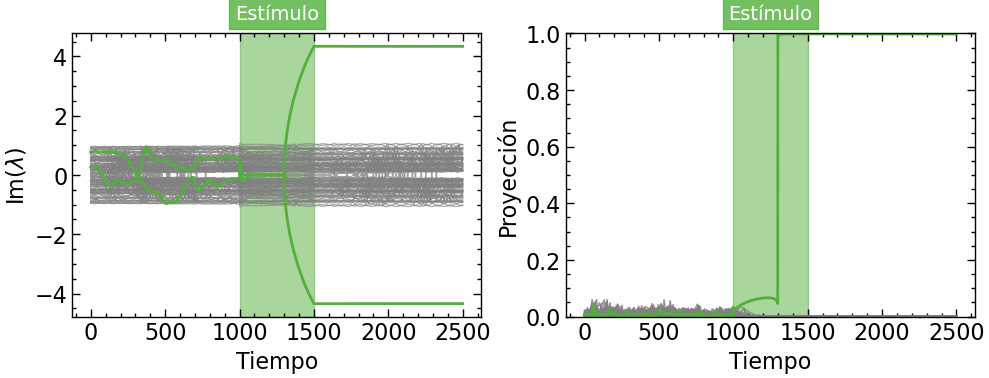

In [204]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

def generar_OU_plano(time_span, u, v, theta=1.0, sigma=0.5, m0=0.0, n0=0.0):
    """
    Simula un caminante de Ornstein-Uhlenbeck en el plano generado por u y v
    usando el método de Euler-Maruyama.
    """
    num_steps = len(time_span)
    dim = len(u)
    
    # Aseguramos que u y v sean vectores columna unitarios o del tamaño correcto
    u = np.asarray(u)
    v = np.asarray(v)
    
    # Inicializamos las trayectorias de los coeficientes m(t) y n(t)
    m = np.zeros(num_steps)
    n = np.zeros(num_steps)
    m[0] = m0
    n[0] = n0
    
    # Matriz para guardar el vector b(t) en cada instante temporal
    b_t_series = np.zeros((num_steps, dim))
    b_t_series[0] = m[0] * u + n[0] * v
    
    # Simulación Euler-Maruyama
    for i in range(1, num_steps):
        dt = time_span[i] - time_span[i-1]
        sqrt_dt = np.sqrt(dt)
        
        # Actualización de Ornstein-Uhlenbeck para m y n
        dm = -theta * m[i-1] * dt + sigma * sqrt_dt * np.random.normal()
        dn = -theta * n[i-1] * dt + sigma * sqrt_dt * np.random.normal()
        
        m[i] = m[i-1] + dm
        n[i] = n[i-1] + dn
        
        # Construcción del vector en el plano uv
        b_t_series[i] = m[i] * u + n[i] * v
        
    return b_t_series

def STDP_system(t, y, dim, alpha, tau, I_dim, b_input):
    X = y[:dim]
    Y = y[dim:2*dim]
    W = y[2*dim:].reshape((dim, dim))

    # I_dim ya viene precalculada para evitar alocación de memoria constante
    dWdt = alpha * (I_dim - np.outer(X, X) + np.outer(X, Y) - np.outer(Y,X))
    dXdt = W @ X + b_input(t)
    dYdt = 1 / tau * (X - Y)

    return np.concatenate([dXdt, dYdt, dWdt.flatten()])

def Simular_STDP(X_0, Y_0, W_0, alpha, tau, b_input, time_span):
    dim = X_0.shape[0]
    I_dim = np.eye(dim) # Precalculamos la identidad aquí

    y_0 = np.concatenate([X_0, Y_0, W_0.flatten()])
    solution = solve_ivp(fun=STDP_system, 
                         t_span=[0, time_span[-1]], 
                         y0=y_0, 
                         args=[dim, alpha, tau, I_dim, b_input], # Pasamos I_dim
                         t_eval=time_span, 
                         method='DOP853')

    if solution.success:
        X = solution.y[:dim, :].transpose()
        Y = solution.y[dim:2*dim, :].transpose()
        W = solution.y[2*dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)
        print("Integración completada")
        return X, Y, W
    else:
        print("No se pudo integrar correctamente")
        return None, None, None

def cos_proyeccion_hiperespacio_opt(x, y, Q_2):
    plano_1 = np.column_stack((x, y))
    Q_1, _ = np.linalg.qr(plano_1)
    
    # Q_2 ya viene listo de fuera
    M = Q_1.T @ Q_2
    
    cos_angulos_principales = np.linalg.svd(M, compute_uv=False)
    cos_angulos_principales = np.clip(cos_angulos_principales, -1.0, 1.0)
    
    return np.prod(cos_angulos_principales)

# --- Configuración Inicial ---
dim = 100
alpha = 0.001
tau = 500
rho = 50
freq = 0.5 / tau

rng = np.random.default_rng()
W_0 = rng.normal(0, 1 / np.sqrt(dim), (dim, dim))
X_0 = rng.normal(0, 1 / np.sqrt(dim), dim)
Y_0 = X_0
t_eval_init = np.array([1.5 / alpha])
t_eval_pre = np.linspace(0, 1000, 100)
t_eval_learning = np.linspace(0, 500, 1000)
t_eval_post = np.linspace(0, 1000, 100)

u = rng.standard_normal(dim)
u = u / np.linalg.norm(u)

v = rng.standard_normal(dim)
v = v - np.dot(u, v) * u
v = v / np.linalg.norm(v)

# b_noisy = generar_OU_plano(t_eval_learning, u, v) * rho
b_noisy = rho * (np.sin(2 * np.pi * freq * t_eval_learning)[:, None] * u[None, :] + np.cos(2 * np.pi * freq * t_eval_learning)[:, None] * v[None, :])
# b_noisy = np.full((t_eval_learning.shape[0], dim), rho * (u + v))
b_input = interp1d(t_eval_learning, b_noisy, axis=0, kind='linear', fill_value="extrapolate")
input_nulo = lambda t: np.zeros(dim)

# PRECALCULO CRÍTICO: Como u y v ya son ortonormales, su column_stack ya es la matriz Q_2
Q_2_precalculada = np.column_stack((u, v))

# --- Simulaciones ---
X_init, Y_init, W_init = Simular_STDP(X_0, Y_0, W_0, alpha, tau, input_nulo, t_eval_init)
X_pre, Y_pre, W_pre = Simular_STDP(X_init[-1], Y_init[-1], W_init[-1], alpha, tau, input_nulo, t_eval_pre)
X_learning, Y_learning, W_learning = Simular_STDP(X_pre[-1], Y_pre[-1], W_pre[-1], alpha, tau, b_input, t_eval_learning)
X_post, Y_post, W_post = Simular_STDP(X_learning[-1], Y_learning[-1], W_learning[-1], alpha, tau, input_nulo, t_eval_post)

# --- Análisis espectral ---
total_W = np.concatenate([W_pre, W_learning, W_post])
total_evals, total_evecs = np.linalg.eig(total_W)

# Asumo que esta función existe en tu entorno
tracked_evals, tracked_evecs = track_eigen_inertia(total_evals, total_evecs)

min_idx = np.argmin(tracked_evals[-1].imag)
max_idx = np.argmax(tracked_evals[-1].imag)

total_time = np.concatenate([t_eval_pre, t_eval_learning + t_eval_pre[-1], t_eval_post + t_eval_learning[-1] + t_eval_pre[-1]])
total_steps = total_time.shape[0]

# --- Bucle de Proyecciones Optimizado ---
all_projections = np.zeros((total_steps, dim))

for t in range(total_steps):
    for i in range(dim):
        x_real = tracked_evecs[t, :, i].real
        y_imag = tracked_evecs[t, :, i].imag
        
        # Pasamos la matriz Q_2 precalculada ahorrando miles de operaciones QR
        all_projections[t, i] = cos_proyeccion_hiperespacio_opt(x_real, y_imag, Q_2_precalculada)

# --- Gráficos ---
plt.close()
plt.style.use(['science', 'notebook'])
plt.figure(figsize=(10, 4))

# Subplot 1
plt.subplot(1, 2, 1)
plt.plot(total_time, np.delete(tracked_evals.imag, [min_idx, max_idx], axis=1), color='gray', alpha=0.6, lw=1)
plt.plot(total_time, tracked_evals[:, [min_idx, max_idx]].imag, color='#53AF3C', alpha=1)
plt.axvspan(t_eval_pre[-1], t_eval_pre[-1] + t_eval_learning[-1], alpha=0.5, color='#53AF3C')
plt.xlabel("Tiempo")
plt.ylabel(r"Im$(\lambda)$")
plt.text(0.5, 1.05, "Estímulo", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))

# Subplot 2
plt.subplot(1, 2, 2)
plt.plot(total_time, np.delete(all_projections, [max_idx, min_idx], axis=1), color='gray', lw=1, alpha=0.6)
plt.plot(total_time, all_projections[:, max_idx], color='#53AF3C')
plt.axvspan(t_eval_pre[-1], t_eval_pre[-1] + t_eval_learning[-1], alpha=0.5, color='#53AF3C')
plt.text(0.5, 1.05, "Estímulo", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))
plt.ylim(0.0, 1.0)
plt.xlabel("Tiempo")
plt.ylabel("Proyección")
plt.tight_layout()
plt.savefig("Figures/STDP correcto.pdf")
plt.show()

## Recuperación del patrón

Integración completada
Integración completada
Integración completada
Integración completada
Integración completada
Integración completada


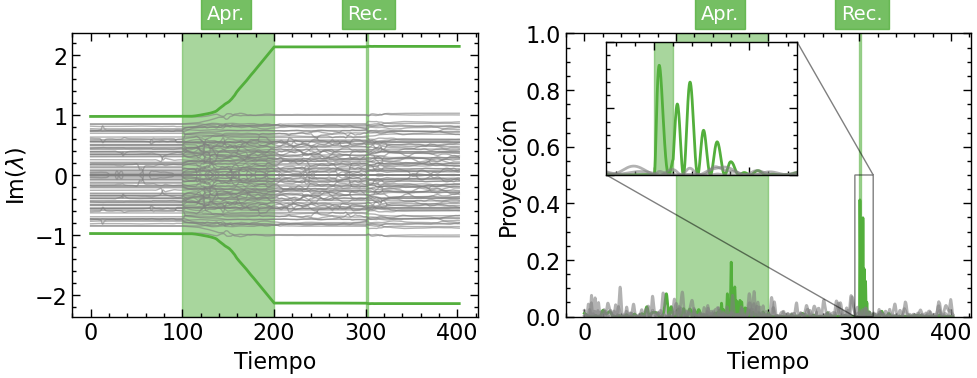

In [27]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

def learing_stimulus_system(t, y, dim, alpha, I_dim, A=0, b_input=0):
    X = y[:dim]
    W = y[dim:].reshape((dim, dim))

    # I_dim ya viene precalculada para evitar alocación de memoria constante
    dWdt = alpha * (I_dim - np.outer(X, X) + A)
    dXdt = W @ X + b_input(t)

    return np.concatenate([dXdt, dWdt.flatten()])

def Simular_learning_stimulus(X_0, W_0, alpha, A, b_input, time_span):
    dim = X_0.shape[0]
    I_dim = np.eye(dim) # Precalculamos la identidad aquí

    y_0 = np.concatenate([X_0, W_0.flatten()])
    solution = solve_ivp(fun=learing_stimulus_system, 
                         t_span=[0, time_span[-1]], 
                         y0=y_0, 
                         args=[dim, alpha, I_dim, A, b_input], # Pasamos I_dim
                         t_eval=time_span, 
                         method='DOP853')

    if solution.success:
        X = solution.y[:dim, :].transpose()
        W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)
        print("Integración completada")
        return X, W
    else:
        print("No se pudo integrar correctamente")
        return None, None

# --- Configuración Inicial ---
dim = 100
alpha = 0.001
tau = 500
rho = 20
input_amp = 20

rng = np.random.default_rng(457)

t_eval_init = np.array([1.5 / alpha])
t_eval_pre = np.linspace(0, 100, 1000)
t_eval_learning = np.linspace(0, 100, 1000)
t_eval_mid = np.linspace(0, 100, 1000)
t_eval_retrieval = np.linspace(0, 2, 100)
t_eval_post = np.linspace(0, 100, 10000)

u = rng.standard_normal(dim)
u = u / np.linalg.norm(u)

v = rng.standard_normal(dim)
v = v - np.dot(u, v) * u
v = v / np.linalg.norm(v)

A = rho * (np.outer(u, v) - np.outer(v, u))
W_0 = rng.normal(0, 1 / np.sqrt(dim), (dim, dim))
X_0 = rng.normal(0, 1 / np.sqrt(dim), dim)

b_noisy = np.full((t_eval_retrieval.shape[0], dim), input_amp * u)
b_input = interp1d(t_eval_retrieval, b_noisy, axis=0, kind='linear', fill_value="extrapolate")
input_nulo = lambda t: np.zeros(dim)


# --- Simulaciones ---
X_init, W_init = Simular_learning_stimulus(X_0, W_0, alpha, 0, input_nulo, t_eval_init)
X_pre, W_pre = Simular_learning_stimulus(X_init[-1], W_init[-1], alpha, 0, input_nulo, t_eval_pre)
X_learning, W_learning = Simular_learning_stimulus(X_pre[-1], W_pre[-1], alpha, A, input_nulo, t_eval_learning)
X_mid, W_mid = Simular_learning_stimulus(X_learning[-1], W_learning[-1], alpha, 0, input_nulo, t_eval_mid)
X_retrieval, W_retrieval = Simular_learning_stimulus(X_mid[-1], W_mid[-1], alpha, 0, b_input, t_eval_retrieval)
X_post, W_post = Simular_learning_stimulus(X_retrieval[-1], W_retrieval[-1], alpha, 0, input_nulo, t_eval_post)

# --- Análisis espectral ---
total_W = np.concatenate([W_pre, W_learning, W_mid, W_retrieval, W_post])
total_evals = np.linalg.eigvals(total_W)

# Asumo que esta función existe en tu entorno
tracked_evals = track_eigenvalues(total_evals)

min_idx = np.argmin(tracked_evals[-1].imag)
max_idx = np.argmax(tracked_evals[-1].imag)

total_time = np.concatenate([t_eval_pre, 
                             t_eval_learning + t_eval_pre[-1], 
                             t_eval_mid + t_eval_learning[-1] + t_eval_pre[-1],
                             t_eval_retrieval + t_eval_mid[-1] + t_eval_learning[-1] + t_eval_pre[-1],
                             t_eval_post + t_eval_retrieval[-1] + t_eval_mid[-1] + t_eval_learning[-1] + t_eval_pre[-1]])
total_steps = total_time.shape[0]

# --- Bucle de Proyecciones Optimizado ---
total_X = np.concatenate([X_pre, X_learning, X_mid, X_retrieval, X_post])
total_X_norm = np.linalg.norm(total_X, axis=1)

p_u = np.einsum('i,ti->t', u, total_X) / total_X_norm

random_dir1 = rng.standard_normal(dim)
random_dir1 = random_dir1 / np.linalg.norm(random_dir1)
p_random1 = np.einsum('i,ti->t', random_dir1, total_X) / total_X_norm

random_dir2 = rng.standard_normal(dim)
random_dir2 = random_dir2 / np.linalg.norm(random_dir2)
p_random2 = np.einsum('i,ti->t', random_dir2, total_X) / total_X_norm

random_dir3 = rng.standard_normal(dim)
random_dir3 = random_dir3 / np.linalg.norm(random_dir3)
p_random3 = np.einsum('i,ti->t', random_dir3, total_X) / total_X_norm

# --- Gráficos ---
plt.close()
plt.style.use(['science', 'notebook'])
plt.figure(figsize=(10, 4))

# Subplot 1
plt.subplot(1, 2, 1)
# plt.plot(total_time, np.delete(tracked_evals.imag, [min_idx, max_idx], axis=1), color='gray', alpha=0.6, lw=1)
# plt.plot(total_time, tracked_evals[:, [min_idx, max_idx]].imag, color='#53AF3C', alpha=1)
plt.plot(total_time, np.delete(tracked_evals.imag, [min_idx, max_idx], axis=1), color='gray', alpha=0.6, lw=1)
plt.plot(total_time, tracked_evals[:, [min_idx, max_idx]].imag, color='#53AF3C', alpha=1)
plt.axvspan(t_eval_pre[-1], t_eval_pre[-1] + t_eval_learning[-1], alpha=0.5, color='#53AF3C')
plt.axvspan(t_eval_pre[-1] + t_eval_learning[-1] + t_eval_mid[-1], t_eval_pre[-1] + t_eval_learning[-1] + t_eval_mid[-1] + t_eval_retrieval[-1], alpha=0.5, color='#53AF3C')
plt.xlabel("Tiempo")
plt.ylabel(r"Im$(\lambda)$")
plt.text(0.38, 1.05, "Apr.", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))
plt.text(0.73, 1.05, "Rec.", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))
# Subplot 2
plt.subplot(1, 2, 2)
plt.plot(total_time, p_u**2, color='#53AF3C')
plt.plot(total_time, p_random1**2, color='gray', alpha=0.6)
plt.plot(total_time, p_random2**2, color='gray', alpha=0.6)
plt.plot(total_time, p_random3**2, color='gray', alpha=0.6)
plt.axvspan(t_eval_pre[-1], t_eval_pre[-1] + t_eval_learning[-1], alpha=0.5, color='#53AF3C')
plt.axvspan(t_eval_pre[-1] + t_eval_learning[-1] + t_eval_mid[-1], t_eval_pre[-1] + t_eval_learning[-1] + t_eval_mid[-1] + t_eval_retrieval[-1], alpha=0.5, color='#53AF3C')
plt.text(0.38, 1.05, "Apr.", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))
plt.text(0.73, 1.05, "Rec.", transform=plt.gca().transAxes, color='white', ha='center', fontsize=14,
         bbox=dict(boxstyle='square,pad=0.3', facecolor='#53AF3C', edgecolor='#53AF3C', alpha=0.8))
plt.xlabel("Tiempo")
plt.ylabel("Proyección")
plt.ylim(0, 1)

x1, x2, y1, y2 = 295, 315, 0, 0.5
axins = plt.gca().inset_axes(
    [0.1, 0.5, 0.47, 0.47],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins.plot(total_time, p_u**2, color='#53AF3C')
axins.plot(total_time, p_random1**2, color='gray', alpha=0.6)
axins.plot(total_time, p_random2**2, color='gray', alpha=0.6)
axins.plot(total_time, p_random3**2, color='gray', alpha=0.6)
axins.axvspan(t_eval_pre[-1] + t_eval_learning[-1] + t_eval_mid[-1], t_eval_pre[-1] + t_eval_learning[-1] + t_eval_mid[-1] + t_eval_retrieval[-1], alpha=0.5, color='#53AF3C')
plt.gca().indicate_inset_zoom(axins, edgecolor="black")
plt.tight_layout()
plt.savefig("Figures/retrieval.pdf")
plt.show()

## Integrador con fugas

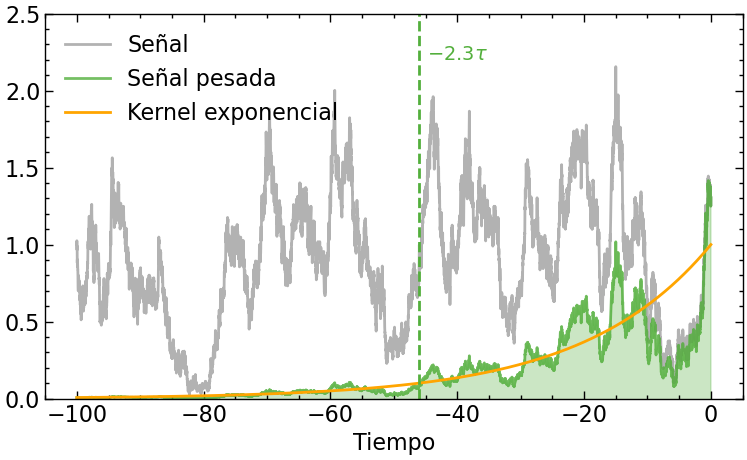

In [178]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(436)
tau = 20
theta = 0.5
sigma = 0.5
K = 1
steps = 10000
time = np.linspace(-100, 0, steps)
X = np.ones(steps) * K
for i in range(1, steps):
    dt = 0.001
    dmudt = X[i-1] * (1 - X[i-1]/K)
    dWdt = sigma *  np.random.randn()
    X[i] = X[i-1] + dt * dmudt + np.sqrt(dt) * dWdt

kernel = np.exp(time / tau)

plt.close()
plt.style.use(['science', 'notebook'])
plt.figure(figsize=(9, 5))

plt.plot(time, X**2, label='Señal', color='grey', alpha=0.6)
plt.plot(time, X**2 * kernel, label='Señal pesada', color='#53AF3C', alpha=0.8)
plt.plot(time, kernel, label='Kernel exponencial', color='orange', ls='-')
plt.fill_between(time, -5, X**2 * kernel, color='#53AF3C', alpha=0.3)
plt.axvline(-2.3 * tau, ls='--', color='#53AF3C')
plt.text(-2 * tau, 2.2, r"$-2.3\tau$", color='#53AF3C', ha='center', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo')
plt.ylim(0, 2.5)
plt.legend(loc='upper left')
plt.savefig('Figures/leaky integrator.pdf')
plt.show()

## Flechas desfasadas

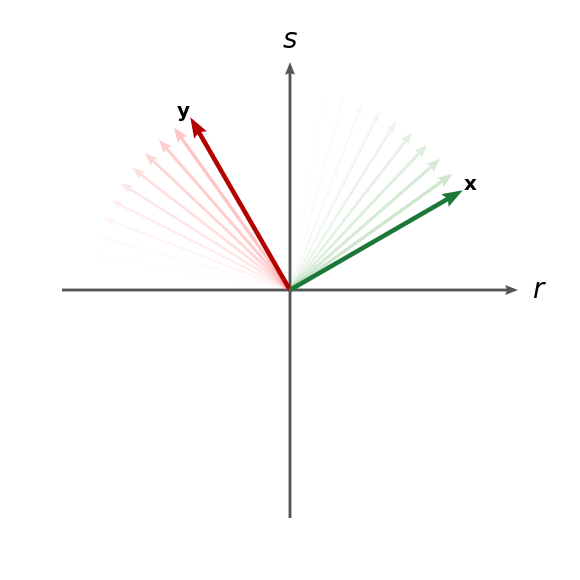

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def draw_shaded_vector(ax, origin, vector, color, num_shadows=8, angle_spread=45, direction='cw'):
    """
    Dibuja un vector principal y un abanico de sombras con puntas de flecha correctas.
    """
    v_u, v_v = vector
    angle = np.arctan2(v_v, v_u)
    length = np.linalg.norm(vector)

    # Configuración de color
    if color == 'red':
        main_color = '#b30000'       # Rojo oscuro/intenso
        shadow_base = '#ff6666'      # Rojo claro para sombras
    else:
        main_color = '#1b7837'       # Verde oscuro/intenso
        shadow_base = '#7fbf7b'      # Verde claro para sombras

    # Cálculo de ángulos para el abanico de sombras
    if direction == 'ccw':
        angles = np.linspace(angle + np.radians(angle_spread), angle, num_shadows + 1)
    else:
        angles = np.linspace(angle - np.radians(angle_spread), angle, num_shadows + 1)

    # 1. Dibujar las sombras (posiciones previas)
    for i in range(num_shadows):
        # Transparencia progresiva (más tenue cuanto más antigua es la posición)
        alpha = ((i + 1) / (num_shadows + 1)) ** 1.5 * 0.45
        
        # Grosor progresivo
        width = 0.003 + (i / num_shadows) * 0.003
        
        shadow_u = length * np.cos(angles[i])
        shadow_v = length * np.sin(angles[i])
        
        # Ajuste exacto de cabezal (headlength > headaxislength garantiza forma de flecha)
        ax.quiver(origin[0], origin[1], shadow_u, shadow_v, 
                  angles='xy', scale_units='xy', scale=1, 
                  color=shadow_base, alpha=alpha, width=width,
                  headwidth=3.5, headlength=4.5, headaxislength=4.0)

    # 2. Dibujar el vector principal actual (en primer plano)
    ax.quiver(origin[0], origin[1], v_u, v_v, 
              angles='xy', scale_units='xy', scale=1, 
              color=main_color, width=0.008, 
              headwidth=3.2, headlength=4.5, headaxislength=4.0)

# Configuración del lienzo y ejes
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)

# Dibujar ejes de coordenadas principal (u, v) con puntas de flecha correctas
ax.quiver(-3.2, 0, 6.4, 0, angles='xy', scale_units='xy', scale=1, color='#555555', 
          width=0.005, headwidth=3.5, headlength=4.5, headaxislength=4.0)
ax.quiver(0, -3.2, 0, 6.4, angles='xy', scale_units='xy', scale=1, color='#555555', 
          width=0.005, headwidth=3.5, headlength=4.5, headaxislength=4.0)

# Etiquetas de los ejes
ax.text(3.5, 0, '$r$', fontsize=20, ha='center', va='center', family='serif', style='italic')
ax.text(0, 3.5, '$s$', fontsize=20, ha='center', va='center', family='serif', style='italic')

# Definir vectores (desfasados entre sí)
length = 2.8
vec_red = np.array([length * np.cos(np.radians(120)), length * np.sin(np.radians(120))])
vec_green = np.array([length * np.cos(np.radians(30)), length * np.sin(np.radians(30))])

ax.text(vec_green[0]+0.1, vec_green[1], 'x', ha='center', fontsize='x-large', fontweight='bold')
ax.text(vec_red[0]-0.1, vec_red[1], 'y', ha='center', fontsize='x-large', fontweight='bold')
# Generar vectores con sus sombras en rotación
draw_shaded_vector(ax, (0, 0), vec_red, color='red', direction='ccw', num_shadows=9, angle_spread=50)
draw_shaded_vector(ax, (0, 0), vec_green, color='green', direction='ccw', num_shadows=9, angle_spread=50)

# Limpiar visualización
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

plt.tight_layout()
plt.savefig('Figures/rotacion.pdf')
plt.show()